# Simplified Implementation of V3 Methodology
In this notebook we'll implement the V3 Methodology developped after our call with M. Weibel. Generally speaking it combined V1 and V2 into a single unified methodology. Concretely this means:
- One set of features is the time-decayed average count of articles, separated into topics
- Second set of features is the time-decayed average embedding, followed by PCA dimension reduction.

A few limitation of this implementation:
- We'll only use the german_news_v1 dataset obtained in `/data`, because we haven't implemented any translation or finer preprocessing
- We'll use the `energy-charts.info` API, which can only return auction price, not spot price yet. This is because we haven't yet downloaded the entire relevant dataset yet.
- We will not run any hyperparameter-tuning in this notebook yet.

We'll make sure to code this notebook somewhat modular so that swapping out these features for the final notebook is easier.

---
## Importing Required Libraries
This section imports all necessary libraries for running the analysis in this notebook

In [1]:
# Core libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from tqdm import tqdm

# API libraries
import requests
import os
from dotenv import load_dotenv

# NLP libraries
import umap
import torch
from transformers import pipeline
from sentence_transformers import SentenceTransformer
from datasets import Dataset

# ML Libraries
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# Parallelization libraries
from joblib import Parallel, delayed

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
# Data Collection & Loading
## News Data
Here we only need to import `german_news_v1.csv` into a dataframe since we already collected and somewhat pre-processed it

In [2]:
news_df = pd.read_csv('german_news_v1.csv')

print(news_df.shape)
news_df.head(5)

(117138, 5)


,publishedAt,title,source,description,url
0,2020-11-01 07:10:56+00:00,Pandemische Echtzeitradikalisierung der Corona...,Spiegel Online,Die Bewegung der Corona-Leugner ist nicht mehr...,https://www.spiegel.de/netzwelt/web/pandemisch...
1,2020-11-01 07:57:31+00:00,Bis 2030 - Audi-Chef Duesmann: Verbrenner wird...,Focus,"Audi-Chef Duesmann glaubt nicht, dass sich Was...",https://www.focus.de/finanzen/boerse/bis-2030-...
2,2020-11-01 08:29:51+00:00,"""Ständige Vertretung"" - Rache für den Lockdown...",Focus,Wegen des anstehenden Lockdowns sind viele Wir...,https://www.focus.de/politik/deutschland/reakt...
3,2020-11-01 09:30:16+00:00,*** BILDplus Inhalt *** Frischluft gegen Coron...,Bild,"Weil Corona durch Aerosole übertragen wird, he...",https://www.bild.de/bild-plus/ratgeber/2020/ra...
4,2020-11-01 10:27:14+00:00,"US-Wahl: ""Trump hat mich zur Miss Pennsylvania...",Spiegel Online,Dank Trump war Gina Cerilli ein erfolgreiches ...,https://www.spiegel.de/politik/ausland/us-wahl...


In [3]:
# Remove in final run

# Only keep articles from 2025-01-01 onwards
news_df = news_df[news_df['publishedAt'] >= '2025-01-01']

# Remove everything but 500 random articles to keep training light
news_df = news_df.sample(500)

## Energy Data
Similar to V1 and V2 implementation we'll use the `energy-charts.info` API to pull 1 year worth of data for the auction price (which we will assume to be spot price in this notebook) and the total power generated.

In [4]:
def fetch_energy_charts_data(start_date: str, end_date: str, bidding_zone: str = 'DE-LU') -> pd.DataFrame:
    """
    Fetch hourly price and power generation data from Energy Charts API.
    
    Parameters:
        start_date (str): Start date in format 'YYYY-MM-DD'
        end_date (str): End date in format 'YYYY-MM-DD'
        bidding_zone (str): Bidding zone code (default: 'DE-LU' for Germany/Luxembourg)
    
    Returns:
        pd.DataFrame: DataFrame with datetime index and columns: 'price', 'total_power'
    """
    base_url = "https://api.energy-charts.info"
    
    price_url = f"{base_url}/price"
    price_params = {
        'bzn': bidding_zone,
        'start': start_date,
        'end': end_date
    }
    
    try:
        price_response = requests.get(price_url, params=price_params, timeout=30)
        price_response.raise_for_status()
        price_data = price_response.json()
    except requests.exceptions.RequestException as e:
        raise requests.exceptions.RequestException(f"Error fetching price data: {e}")
    
    power_url = f"{base_url}/total_power"
    power_params = {
        'country': 'de',
        'start': start_date,
        'end': end_date
    }
    
    try:
        power_response = requests.get(power_url, params=power_params, timeout=30)
        power_response.raise_for_status()
        power_data = power_response.json()
    except requests.exceptions.RequestException as e:
        raise requests.exceptions.RequestException(f"Error fetching power data: {e}")
    
    if 'unix_seconds' in price_data and 'price' in price_data:
        price_timestamps = pd.to_datetime(price_data['unix_seconds'], unit='s')
        prices = price_data['price']
        price_df = pd.DataFrame({'price': prices}, index=price_timestamps)
    else:
        raise ValueError("Unexpected price data structure")
    
    if 'unix_seconds' in power_data and 'production_types' in power_data:
        power_timestamps = pd.to_datetime(power_data['unix_seconds'], unit='s')
        
        total_power = np.zeros(len(power_timestamps))
        for production_type in power_data['production_types']:
            try:
                production_values = np.array(production_type['data'])
                total_power += production_values
            except Exception:
                continue
        
        power_df = pd.DataFrame({'total_power': total_power}, index=power_timestamps)
    else:
        raise ValueError("Unexpected power data structure")
    
    energy_df = price_df.join(power_df, how='outer')
    
    return energy_df

start_date = "2025-01-01"
end_date = "2025-10-31"


energy_df = fetch_energy_charts_data(start_date, end_date)
energy_df.head(5)


,price,total_power
2024-12-31 23:00:00,2.16,113506.4
2024-12-31 23:15:00,NaN,111478.1
2024-12-31 23:30:00,NaN,111041.0
2024-12-31 23:45:00,NaN,110492.7
2025-01-01 00:00:00,1.60,109574.1


In [5]:
# We get quarterly data for power, but hourly for price. We just drop NaN rows
energy_df = energy_df.dropna()
energy_df.head(5)

,price,total_power
2024-12-31 23:00:00,2.16,113506.4
2025-01-01 00:00:00,1.60,109574.1
2025-01-01 01:00:00,0.00,107039.7
2025-01-01 02:00:00,-0.01,105082.2
2025-01-01 03:00:00,-0.01,101609.3


---
# Feature Engineering
In this section we'll be computing the different features used in training our baseline and advanced models.

## Data Initialisation & Baseline Features
1. We copy the `energy_df`into `master_df`

2. We need to copy and shift the `price` column 24h back into `target` since our target variable is the next day price

3. We create a few lagged features:

    3.1. `price_lag_24` and `price_lag_168`

    3.2. `total_power_lag_24` and `total_power_lag_168`

4. Also create temporal features like `hour`, `week_of_year`, `month`, `day_of_week`, `day_of_year` and `week_of_year` to help with seasonality

5. Drop NaN values because of the shifts

In [6]:
master_df = energy_df.copy()

master_df['target'] = master_df['price'].shift(-24)

master_df['price_lag_24'] = master_df['price'].shift(24)
master_df['price_lag_168'] = master_df['price'].shift(168)
master_df['total_power_lag_24'] = master_df['total_power'].shift(24)
master_df['total_power_lag_168'] = master_df['total_power'].shift(168)

master_df['hour'] = master_df.index.hour
master_df['week_of_year'] = master_df.index.isocalendar().week
master_df['month'] = master_df.index.month
master_df['day_of_week'] = master_df.index.dayofweek
master_df['day_of_year'] = master_df.index.dayofyear

master_df = master_df.dropna()

print(master_df.columns)
master_df.head(25)

Index(['price', 'total_power', 'target', 'price_lag_24', 'price_lag_168',
       'total_power_lag_24', 'total_power_lag_168', 'hour', 'week_of_year',
       'month', 'day_of_week', 'day_of_year'],
      dtype='object')


,price,total_power,target,price_lag_24,price_lag_168,total_power_lag_24,total_power_lag_168,hour,week_of_year,month,day_of_week,day_of_year
2025-01-07 23:00:00,71.05,131382.6,101.44,19.07,2.16,113247.3,113506.4,23,2,1,1,7
2025-01-08 00:00:00,68.01,126774.1,100.00,8.71,1.60,110138.0,109574.1,0,2,1,2,8
2025-01-08 01:00:00,63.34,124274.4,98.77,8.90,0.00,105867.7,107039.7,1,2,1,2,8
2025-01-08 02:00:00,57.01,126855.3,95.22,5.01,-0.01,105542.6,105082.2,2,2,1,2,8
2025-01-08 03:00:00,66.29,130570.5,98.28,5.13,-0.01,108462.1,101609.3,3,2,1,2,8
2025-01-08 04:00:00,72.07,137559.1,102.65,5.80,-0.06,115604.9,101208.7,4,2,1,2,8
2025-01-08 05:00:00,82.70,155676.6,133.54,48.86,-0.09,134886.4,98277.8,5,2,1,2,8
2025-01-08 06:00:00,100.73,177650.3,148.80,76.83,-0.01,156199.4,97783.4,6,2,1,2,8
2025-01-08 07:00:00,128.22,188674.5,164.88,85.08,-0.01,170216.8,103032.4,7,2,1,2,8
2025-01-08 08:00:00,108.18,192136.3,156.15,84.24,-0.04,173150.9,105229.5,8,2,1,2,8


## Topic Count Features
First we define 13 topics to classify news headlines into. These will be changed and optimised later down the line. 
2) 

In [7]:
candidate_labels = [
    # Energy consumption
    "der Strom- oder Energieverbrauch steigt deutlich",
    "der Strom- oder Energieverbrauch sinkt deutlich",

    # Energy production / generation availability
    "die Erzeugung oder Verfügbarkeit von Strom oder Energie steigt",
    "die Erzeugung oder Verfügbarkeit von Strom oder Energie sinkt",

    # Commodity prices (gas/coal/oil)
    "die Preise für Erdgas, Kohle oder Öl steigen stark",
    "die Preise für Erdgas, Kohle oder Öl fallen stark",

    # Geopolitik und Versorgung
    "es gibt zunehmende geopolitische Spannungen oder Lieferengpässe bei Energie",
    "die geopolitischen Spannungen und Versorgungsprobleme gehen zurück",

    # Auswirkungen von Wetter in Deutschland auf Strompreise
    "in Deutschland gibt es kaltes Wetter, wenig Wind oder wenig Sonne mit möglichen Auswirkungen auf die Strompreise",
    "in Deutschland gibt es mildes oder warmes Wetter, viel Wind oder viel Sonne mit möglichen Auswirkungen auf die Strompreise",

    # Finanzmärkte
    "an den Finanzmärkten herrscht Instabilität oder Turbulenz",
    "an den Finanzmärkten herrscht Stabilität oder Beruhigung",

    # Catch-all
    "der Text hat keinen Bezug zu Energiepreisen, Wetter oder Finanzmärkten"
]

hypothesis_template = "Dieser Text legt nahe, dass {}."

We use Zero-Shot Classification to try and classify our news into the 13 topics as defined above. Some more work is needed when it comes to pre-processing and hypothesis crafting to ensure not too many articles fall into the catch-all category.

We use `ahajtomar/German_Zeroshot` as a model here, because it is a little bit more lightweight. In future itterations we might want to use `nahiar/zero-shot-classification` or another larger model for better results.

We also first try to classify news on their headline, since it's shorter and more efficient, then run through any articles that fell into the catch-all category again, but using their longer article description.

In [8]:
# GPU Optimization Settings
import os
# Set tokenizer parallelism to avoid warnings and improve performance
os.environ["TOKENIZERS_PARALLELISM"] = "true"

# Enable torch optimizations for better GPU utilization
torch.backends.cudnn.benchmark = True  # Optimize for consistent input sizes
if torch.cuda.is_available():
    torch.cuda.empty_cache()  # Clear any cached memory

# Check for device availability in order: CUDA -> MPS -> CPU
if torch.cuda.is_available():
    device = 0
    num_gpus = torch.cuda.device_count()
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / (1024**3)  # GB
    print(f"CUDA available: Using GPU 0 ({gpu_name})")
    print(f"GPU Memory: {gpu_memory:.1f} GB")
    print(f"Total GPUs: {num_gpus}")
    
    # Optimize batch size based on GPU memory
    # Larger GPUs (>16GB) can handle larger batches
    if gpu_memory >= 24:
        optimal_batch_size = 512
    elif gpu_memory >= 16:
        optimal_batch_size = 384
    elif gpu_memory >= 8:
        optimal_batch_size = 256
    else:
        optimal_batch_size = 128
    print(f"Optimal batch size for GPU: {optimal_batch_size}")
elif torch.backends.mps.is_available():
    device = "mps"
    optimal_batch_size = 256  # MPS typically handles this well
    print("MPS available: Using Apple Silicon GPU")
else:
    device = -1
    optimal_batch_size = 32
    print("No GPU available: Using CPU")

# Initialize pipeline with optimized settings
# Using fp16 (half precision) for faster inference and lower VRAM usage
classifier = pipeline(
    "zero-shot-classification",
    model="Sahajtomar/German_Zeroshot",
    device=device,
    batch_size=optimal_batch_size,
    torch_dtype=torch.float16 if device != -1 and device != "mps" else torch.float32  # fp16 on CUDA only

)

def classify_batch(texts, labels, hypothesis_template, batch_size=None, show_progress=True):
    """Classify a batch of texts using zero-shot classification with optimized GPU processing."""
    # Use optimal batch size if not specified
    if batch_size is None:
        batch_size = optimal_batch_size
    
    valid_texts = []
    valid_indices = []
    
    for idx, text in enumerate(texts):
        if pd.notna(text) and text.strip() != '':
            valid_texts.append(text)
            valid_indices.append(idx)

    if not valid_texts:
        return {}, {}

    classifications_dict = {}
    scores_dict = {}

    if show_progress:
        print(f"Processing {len(valid_texts)} texts with batch_size={batch_size} for efficient GPU utilization...")
    
    # Pass all texts at once - the pipeline will batch them internally
    # This approach eliminates sequential processing and maximizes GPU throughput
    # The pipeline uses the optimized batch_size and fp16 precision for better performance
    results = classifier(
        valid_texts,  # Pass all texts at once - pipeline handles batching
        labels,
        hypothesis_template=hypothesis_template,
        multi_label=False
    )
    
    # Handle both single result (dict) and multiple results (list)
    if isinstance(results, dict):
        results = [results]
    
    # Map results back to original indices
    for i, (idx, result) in enumerate(zip(valid_indices, results)):
        classifications_dict[idx] = result['labels'][0]
        scores_dict[idx] = result['scores'][0]

    # Fill in None for invalid texts
    for idx in range(len(texts)):
        if idx not in classifications_dict:
            classifications_dict[idx] = None
            scores_dict[idx] = 0.0

    return classifications_dict, scores_dict

titles = news_df['title'].tolist()
classifications_dict, scores_dict = classify_batch(
    titles, candidate_labels, hypothesis_template, batch_size=optimal_batch_size, show_progress=True
)

news_df['classification'] = [classifications_dict[i] for i in range(len(news_df))]
news_df['classification_score'] = [scores_dict[i] for i in range(len(news_df))]

other_mask = news_df['classification'] == "other (not related to these energy price drivers)"
num_other = other_mask.sum()

if num_other > 0:
    other_indices = news_df[other_mask].index
    descriptions = news_df.loc[other_indices, 'description'].tolist()
    
    other_classifications_dict, other_scores_dict = classify_batch(
        descriptions, candidate_labels, hypothesis_template, batch_size=optimal_batch_size, show_progress=True
    )
    
    for i, idx in enumerate(other_indices):
        news_df.loc[idx, 'classification'] = other_classifications_dict[i]
        news_df.loc[idx, 'classification_score'] = other_scores_dict[i]

final_other = (news_df['classification'] == "es ist nichts mit Energiepreisen, Wetter oder Finanzmärkten zu tun hat").sum()

print(f"Classification completed: {len(news_df)} articles processed")
print(f"Articles classified as 'other': {final_other} ({final_other/len(news_df)*100:.1f}%)")
print(f"\nClassification distribution:")
print(news_df['classification'].value_counts())
print(f"\nAverage score: {news_df['classification_score'].mean():.3f}")
print(f"Median score: {news_df['classification_score'].median():.3f}")

MPS available: Using Apple Silicon GPU


`torch_dtype` is deprecated! Use `dtype` instead!
Device set to use mps


Processing 499 texts with batch_size=256 for efficient GPU utilization...
Classification completed: 500 articles processed
Articles classified as 'other': 0 (0.0%)

Classification distribution:
classification
an den Finanzmärkten herrscht Instabilität oder Turbulenz                                                                     142
in Deutschland gibt es kaltes Wetter, wenig Wind oder wenig Sonne mit möglichen Auswirkungen auf die Strompreise              129
in Deutschland gibt es mildes oder warmes Wetter, viel Wind oder viel Sonne mit möglichen Auswirkungen auf die Strompreise    114
die Erzeugung oder Verfügbarkeit von Strom oder Energie sinkt                                                                  59
die Erzeugung oder Verfügbarkeit von Strom oder Energie steigt                                                                 18
der Strom- oder Energieverbrauch sinkt deutlich                                                                                10
der Strom- 

In [9]:
print(news_df.head(5))

                      publishedAt  \
68226   2025-09-01 12:20:56+00:00   
110074  2025-04-01 11:12:03+00:00   
67739   2025-08-22 10:05:41+00:00   
114849  2025-08-26 05:29:20+00:00   
57353   2025-01-18 04:16:20+00:00   

                                                    title    source  \
68226   Infrastruktur: Energiewende: Baubeginn für Str...  Die Zeit   
110074  Wirtschafts-News - "Kriegswirtschaft": Europa ...     Focus   
67739   Vertraulich! - Söder in Geheimmission auf Helg...      Bild   
114849  „Grobe Fahrlässigkeit“ - Trump schmeißt Fed-Go...      Bild   
57353   Arbeitnehmer: Zahl der Betriebsräte fällt laut...  Die Zeit   

                                              description  \
68226   Hier finden Sie Informationen zu dem Thema „In...   
110074  Europa will von sich aus "verteidigungsfähig w...   
67739   Im BILD-Talk „Vertraulich!“ verrät Politik-Che...   
114849  US-Präsident Donald Trump forderte von der Zen...   
57353   1996 wurde noch knapp die Hälfte der 

## News Embeddings Features
Prior to aggregating topic counts, we will also create the embeddings for each article. We do this, because we want the embedding **with** classification for each article. This is done in case we want to keep or drop the catch-all topic, prior to computing the Time-Decayed weighted average.

In [11]:
def compute_embeddings(show_progress=True):
    """
    Compute embeddings for news headlines (titles only) using a pre-trained model. 
    The full embeddings should be inserted back into the `news_df` dataframe.
    
    Args:
        show_progress (bool): Whether to show a progress bar for the embedding computation.
    
    Returns:
        None (modifies news_df in place)
    """

    # GPU optimization: Clear cache before starting
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()  # Ensure all previous operations are complete
    
    if torch.cuda.is_available():
        device = "cuda"
        num_gpus = torch.cuda.device_count()
        gpu_name = torch.cuda.get_device_name(0)
        gpu_memory = torch.cuda.get_device_properties(0).total_memory / (1024**3)  # GB
        print(f"CUDA available: {num_gpus} GPU(s) detected ({gpu_name})")
        print(f"GPU Memory: {gpu_memory:.1f} GB")
        # Note: SentenceTransformer doesn't support DataParallel - will use first GPU
        use_multi_gpu = False  # Changed: Disable DataParallel wrapping
        
        # Optimize batch size based on GPU memory for embeddings
        if gpu_memory >= 24:
            embedding_batch_size = 512
        elif gpu_memory >= 16:
            embedding_batch_size = 384
        elif gpu_memory >= 8:
            embedding_batch_size = 256
        else:
            embedding_batch_size = 128
    elif torch.backends.mps.is_available():
        device = "mps"
        use_multi_gpu = False
        embedding_batch_size = 256  # MPS typically handles this well
        print("MPS available: Using Apple Silicon GPU")
    else:
        device = "cpu"
        use_multi_gpu = False
        embedding_batch_size = 32
        print("No GPU available: Using CPU")
    
    # Initialize model with optimizations
    # SentenceTransformer automatically handles device placement
    model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2', device=device)
    
    # Convert to half precision on CUDA for faster inference and lower VRAM usage
    if device == "cuda":
        try:
            # Convert model to half precision (fp16) if supported
            model = model.half()
            print("Model converted to fp16 (half precision) for faster GPU inference")
        except Exception as e:
            print(f"Note: Could not convert to fp16: {e}. Continuing with fp32.")
    
    # REMOVED: DataParallel wrapping - SentenceTransformer doesn't support this pattern
    # The model will use the first GPU by default which should be sufficient with proper batching
    
    # Extract only titles for embedding - optimized with list comprehension
    # Use iloc instead of loc to handle non-sequential indices correctly
    texts = [
        (news_df.iloc[idx]['title'] if pd.notna(news_df.iloc[idx]['title']) else '').strip() 
        if pd.notna(news_df.iloc[idx]['title']) else ''
        for idx in range(len(news_df))
    ]
    
    # Filter out empty texts
    valid_texts = [t for t in texts if t.strip() != '']
    valid_indices = [i for i, t in enumerate(texts) if t.strip() != '']
    
    if len(valid_texts) == 0:
        print("Warning: No valid texts found for embedding!")
        return None
    
    # Compute embeddings - let SentenceTransformer handle batching internally
    # This is more reliable, especially on MPS devices
    batch_size = embedding_batch_size
    print(f"Using batch_size={batch_size} for embedding computation")
    print(f"Computing embeddings for {len(valid_texts)} articles using device: {device}")
    
    try:
        # Let SentenceTransformer handle batching internally - more reliable
        embeddings_array = model.encode(
            valid_texts,
            batch_size=batch_size,
            convert_to_numpy=True,
            show_progress_bar=show_progress,
            normalize_embeddings=False
        )
        
        # Create a full array with NaN for invalid texts
        full_embeddings = np.full((len(texts), embeddings_array.shape[1]), np.nan, dtype=np.float32)
        for idx, valid_idx in enumerate(valid_indices):
            full_embeddings[valid_idx] = embeddings_array[idx]
        
        embeddings_array = full_embeddings
        
    except Exception as e:
        print(f"Error computing embeddings: {e}")
        print(f"Error type: {type(e).__name__}")
        import traceback
        traceback.print_exc()
        
        # Try with smaller batch size as fallback
        print(f"\nTrying with smaller batch size (32)...")
        try:
            embeddings_array = model.encode(
                valid_texts,
                batch_size=32,
                convert_to_numpy=True,
                show_progress_bar=show_progress,
                normalize_embeddings=False
            )
            
            # Create a full array with NaN for invalid texts
            full_embeddings = np.full((len(texts), embeddings_array.shape[1]), np.nan, dtype=np.float32)
            for idx, valid_idx in enumerate(valid_indices):
                full_embeddings[valid_idx] = embeddings_array[idx]
            
            embeddings_array = full_embeddings
            
        except Exception as e2:
            print(f"Error with smaller batch size: {e2}")
            raise
    
    # Clear GPU cache after computation
    if device == "cuda":
        torch.cuda.empty_cache()
    elif device == "mps":
        try:
            torch.mps.empty_cache()
        except AttributeError:
            pass  # MPS might not have empty_cache on older PyTorch versions
    news_df['embedding'] = [emb for emb in embeddings_array]
    
    # Final GPU cleanup
    if device == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    
    print(f"Embeddings computed: shape {embeddings_array.shape}")
    print(f"Embedding dimension: {embeddings_array.shape[1]}")
    if device != "cpu":
        if torch.cuda.is_available():
            memory_used = torch.cuda.max_memory_allocated(0) / (1024**3)
            print(f"Peak GPU memory used: {memory_used:.2f} GB")
    
    return None

compute_embeddings(show_progress=True)

MPS available: Using Apple Silicon GPU
Using batch_size=256 for embedding computation
Computing embeddings for 499 articles using device: mps


Batches: 100%|██████████| 2/2 [00:00<00:00,  2.30it/s]

Embeddings computed: shape (500, 384)
Embedding dimension: 384


In [12]:
print(news_df.shape)
print(news_df.head(5))

(500, 8)
                      publishedAt  \
68226   2025-09-01 12:20:56+00:00   
110074  2025-04-01 11:12:03+00:00   
67739   2025-08-22 10:05:41+00:00   
114849  2025-08-26 05:29:20+00:00   
57353   2025-01-18 04:16:20+00:00   

                                                    title    source  \
68226   Infrastruktur: Energiewende: Baubeginn für Str...  Die Zeit   
110074  Wirtschafts-News - "Kriegswirtschaft": Europa ...     Focus   
67739   Vertraulich! - Söder in Geheimmission auf Helg...      Bild   
114849  „Grobe Fahrlässigkeit“ - Trump schmeißt Fed-Go...      Bild   
57353   Arbeitnehmer: Zahl der Betriebsräte fällt laut...  Die Zeit   

                                              description  \
68226   Hier finden Sie Informationen zu dem Thema „In...   
110074  Europa will von sich aus "verteidigungsfähig w...   
67739   Im BILD-Talk „Vertraulich!“ verrät Politik-Che...   
114849  US-Präsident Donald Trump forderte von der Zen...   
57353   1996 wurde noch knapp die Hä

## Time-Decayed Aggregation for Topics
We create a new DataFrame called td_topics_df with a column for the hourly timestamp and one column for each weighted average count of topics.

The rough idea is to have a list of features for all of the 12 topics, which represents how many articles about a certain topic have been released in the two weeks (336h). But instead of a pure count, we'll also calculate an exponentailly time-decayed average. The function should be as follows:

$$weight = e^{- \lambda * HoursSincePublication}$$

This means an article that was released 100h ago will contribute less to the average than an article released 1h ago. Each hour the average should be calculated anew.

For this implementation we'll set the max `lookback_window` to 336h and `lambda` to 0.05 for a smoother decay. In future implmentations these parameters would be fine-tuned.

In [14]:
def compute_time_decayed_topic_counts(news_df, master_df, lookback_window=336, decay_lambda=0.05, verbose=True):
    """
    Compute time-decayed weighted counts for each topic.

    For each timestamp in master_df, compute the weighted average count of articles
    published within the lookback_window, using exponential time decay.

    Weight formula: weight = e^(-lambda * hours_since_publication)

    Parameters:
        news_df: DataFrame with columns ['publishedAt', 'classification', 'embedding']
        master_df: DataFrame with datetime index representing target timestamps
        lookback_window: Number of hours to look back (default: 336h = 2 weeks)
        decay_lambda: Decay rate parameter (default: 0.05)
        verbose: Whether to print progress messages (default: True)

    Returns:
        pd.DataFrame: DataFrame with datetime index and columns for each topic's weighted count
    """
    
    # Convert publishedAt to datetime if needed and handle timezone
    td_topic_news_df = news_df.copy()
    # Handle both publishedAt and publishedAt column names
    if 'publishedAt' in td_topic_news_df.columns:
        td_topic_news_df['publishedAt'] = pd.to_datetime(td_topic_news_df['publishedAt'])
    elif 'publishedAt' in td_topic_news_df.columns:
        td_topic_news_df['publishedAt'] = pd.to_datetime(td_topic_news_df['publishedAt'])
    else:
        raise ValueError("news_df must contain either 'publishedAt' or 'publishedAt' column")
    
    # Convert timezone-aware datetime to naive datetime (remove timezone info)
    if td_topic_news_df['publishedAt'].dt.tz is not None:
        td_topic_news_df['publishedAt'] = td_topic_news_df['publishedAt'].dt.tz_localize(None)

    # Get unique topics (excluding NaN)
    topics = td_topic_news_df['classification'].dropna().unique()

    # Create output DataFrame with same index as master_df
    td_topics_df = pd.DataFrame(index=master_df.index)

    if verbose:
        print(f"Computing time-decayed counts for {len(td_topics_df)} timestamps and {len(topics)} topics")
        print(f"Lookback window: {lookback_window}h, decay lambda: {decay_lambda}")
        print("Using vectorized computation for improved performance...")

    # Vectorized approach: Create a matrix of all timestamps and articles
    timestamps = td_topics_df.index.values
    article_times = td_topic_news_df['publishedAt'].values
    article_topics = td_topic_news_df['classification'].values
    
    # Pre-filter valid articles (those with valid topics)
    valid_mask = pd.notna(article_topics)
    article_times_valid = article_times[valid_mask]
    article_topics_valid = article_topics[valid_mask]
    
    # Create a topic mapping for efficient lookup
    topic_to_idx = {topic: idx for idx, topic in enumerate(topics)}
    
    # Initialize output array: shape (n_timestamps, n_topics)
    weighted_counts_array = np.zeros((len(timestamps), len(topics)))
    
    if verbose:
        print(f"Processing {len(article_times_valid)} valid articles across {len(timestamps)} timestamps")
    
    # Vectorized computation using broadcasting
    # For each timestamp, compute weights for all articles within lookback window
    for i, timestamp in enumerate(tqdm(timestamps, desc="Processing timestamps", leave=True)):
        cutoff_time = timestamp - np.timedelta64(int(lookback_window), 'h')
        
        # Vectorized mask: articles within lookback window
        time_mask = (article_times_valid >= cutoff_time) & (article_times_valid <= timestamp)
        
        if not time_mask.any():
            continue
        
        # Get valid articles for this timestamp
        valid_article_times = article_times_valid[time_mask]
        valid_article_topics = article_topics_valid[time_mask]
        
        # Vectorized hours calculation: (timestamp - article_time) in hours
        hours_since = (timestamp - valid_article_times).astype('timedelta64[h]').astype(float)
        
        # Vectorized weight calculation using exponential decay
        weights = np.exp(-decay_lambda * hours_since)
        
        # Accumulate weights by topic using vectorized operations
        for topic in topics:
            topic_mask = valid_article_topics == topic
            weighted_counts_array[i, topic_to_idx[topic]] = np.sum(weights[topic_mask])
    
    # Convert to DataFrame
    for idx, topic in enumerate(topics):
        td_topics_df[topic] = weighted_counts_array[:, idx]
    
    return td_topics_df

# Compute time-decayed topic counts
td_topics_df = compute_time_decayed_topic_counts(news_df, master_df, lookback_window=336, decay_lambda=0.05)

Computing time-decayed counts for 9339 timestamps and 10 topics
Lookback window: 336h, decay lambda: 0.05
Using vectorized computation for improved performance...
Processing 499 valid articles across 9339 timestamps


Processing timestamps: 100%|██████████| 9339/9339 [00:00<00:00, 26535.62it/s]


In [15]:
print(td_topics_df.shape)
td_topics_df.head(5)

(9339, 10)


,"in Deutschland gibt es mildes oder warmes Wetter, viel Wind oder viel Sonne mit möglichen Auswirkungen auf die Strompreise",der Strom- oder Energieverbrauch steigt deutlich,"in Deutschland gibt es kaltes Wetter, wenig Wind oder wenig Sonne mit möglichen Auswirkungen auf die Strompreise",an den Finanzmärkten herrscht Instabilität oder Turbulenz,die Erzeugung oder Verfügbarkeit von Strom oder Energie sinkt,die Erzeugung oder Verfügbarkeit von Strom oder Energie steigt,an den Finanzmärkten herrscht Stabilität oder Beruhigung,der Strom- oder Energieverbrauch sinkt deutlich,die geopolitischen Spannungen und Versorgungsprobleme gehen zurück,es gibt zunehmende geopolitische Spannungen oder Lieferengpässe bei Energie
2025-01-07 23:00:00,0.158245,0.000500,0.270092,0.005799,0.0,0.000959,0.0,0.140413,0.0,0.0
2025-01-08 00:00:00,0.150527,0.000476,0.256920,0.005517,0.0,0.000912,0.0,0.133565,0.0,0.0
2025-01-08 01:00:00,0.143186,0.000453,0.244390,0.005248,0.0,0.000867,0.0,0.127051,0.0,0.0
2025-01-08 02:00:00,0.136203,0.000431,0.232471,0.004992,0.0,0.000825,0.0,0.120855,0.0,0.0
2025-01-08 03:00:00,0.129560,0.000410,0.221133,0.004748,0.0,0.000785,0.0,0.114961,0.0,0.0


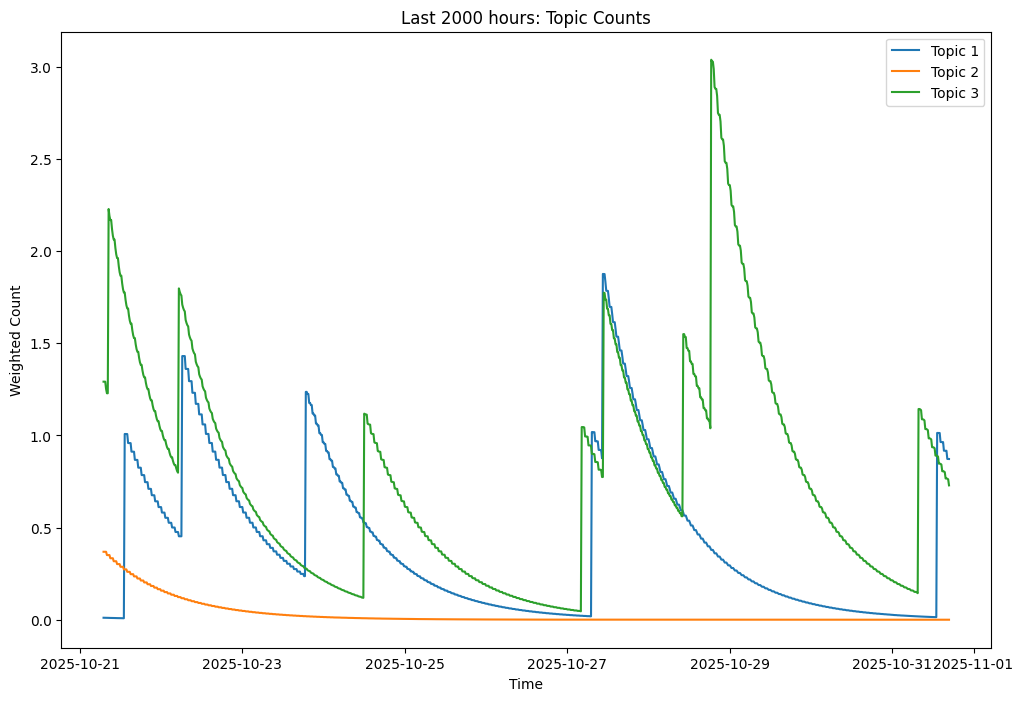

In [16]:
# Quickly graph the weighted counts for the first 2 topics over the past 500 hours to ensure smooth decay

last_500_idx = td_topics_df.index[-1000:] if len(td_topics_df) >= 500 else td_topics_df.index

plt.figure(figsize=(12, 8))
for i in range(3):
    plt.plot(last_500_idx, td_topics_df.loc[last_500_idx, td_topics_df.columns[i]], label=f'Topic {i+1}')
plt.xlabel("Time")
plt.ylabel("Weighted Count")
plt.title("Last 2000 hours: Topic Counts")
plt.legend()
plt.show()

## Time-Decayed Aggregation for Embeddings
We'll create a new Dataframe called `td_embeddings_df` which will be used as features for the models. 

Similar to what we did in the last section, we want to compute the time-decayed weighted average embedding for every hour. We'll use the same parameter values for `lookback_window` = 336h and `lambda` = 0.05 for the function:

$$weight = e^{- \lambda * HoursSincePublication}$$

One minor difference though, is that once these time-decayed weighted average embeddings have been calculated for every hour, we'll use UMAP to reduce the dimensionality of the embeddings to 20. We'll keep this modular as a function in case we want to disable it and use the full embeddings as features. For now we'll reduce dimensionality and put those into `td_embeddings_df`.

In [17]:
def compute_time_decayed_embeddings(news_df, master_df, lookback_window=336, decay_lambda=0.05, verbose=True):
    """
    Compute time-decayed weighted average embeddings (OPTIMIZED VERSION).
    
    For each timestamp in master_df, compute the weighted average embedding of articles
    published within the lookback_window, using exponential time decay.
    
    Weight formula: weight = e^(-lambda * hours_since_publication)
    
    Parameters:
        news_df: DataFrame with columns ['publishedAt', 'embedding']
        master_df: DataFrame with datetime index representing target timestamps
        lookback_window: Number of hours to look back (default: 336h = 2 weeks)
        decay_lambda: Decay rate parameter (default: 0.05)
        verbose: Whether to print progress messages (default: True)
    
    Returns:
        np.ndarray: Array of weighted average embeddings with shape (n_timestamps, embedding_dim)
    """
    
    # Convert publishedAt to datetime if needed and handle timezone
    td_embedding_news_df = news_df.copy()
    if 'publishedAt' in td_embedding_news_df.columns:
        td_embedding_news_df['publishedAt'] = pd.to_datetime(td_embedding_news_df['publishedAt'])
    else:
        raise ValueError("news_df must contain 'publishedAt' column")
    
    # Convert timezone-aware datetime to naive datetime (remove timezone info)
    if td_embedding_news_df['publishedAt'].dt.tz is not None:
        td_embedding_news_df['publishedAt'] = td_embedding_news_df['publishedAt'].dt.tz_localize(None)
    
    if verbose:
        print(f"Computing time-decayed weighted average embeddings for {len(master_df)} timestamps")
        print(f"Lookback window: {lookback_window}h, decay lambda: {decay_lambda}")
        print("Using optimized vectorized computation...")
    
    # OPTIMIZATION 1: Vectorized preprocessing of embeddings
    valid_embeddings_mask = td_embedding_news_df['embedding'].notna()
    if not valid_embeddings_mask.any():
        raise ValueError("No valid embeddings found. Check that news_df has valid embeddings.")
    
    # Get valid indices and process in one go
    valid_indices = td_embedding_news_df[valid_embeddings_mask].index
    
    # Convert embeddings to numpy array efficiently
    article_embeddings_list = []
    for idx in valid_indices:
        emb = td_embedding_news_df.loc[idx, 'embedding']
        if isinstance(emb, list):
            emb = np.array(emb, dtype=np.float32)  # Use float32 for memory efficiency
        elif not isinstance(emb, np.ndarray):
            emb = np.array(emb, dtype=np.float32)
        elif emb.dtype != np.float32:
            emb = emb.astype(np.float32)
        article_embeddings_list.append(emb)
    
    # Get embedding dimension from first valid embedding
    embedding_dim = len(article_embeddings_list[0]) if article_embeddings_list else 384
    
    # Convert to 2D array: shape (n_valid_articles, embedding_dim)
    article_embeddings_array = np.array(article_embeddings_list, dtype=np.float32)
    
    # Get valid article times (much faster than the previous approach)
    article_times_valid = td_embedding_news_df.loc[valid_indices, 'publishedAt'].values
    article_times_valid = pd.to_datetime(article_times_valid).values.astype('datetime64[ns]')
    
    # Sort articles by time for efficient searching
    sort_indices = np.argsort(article_times_valid)
    article_times_valid = article_times_valid[sort_indices]
    article_embeddings_array = article_embeddings_array[sort_indices]
    
    # Initialize output array: shape (n_timestamps, embedding_dim)
    timestamps = master_df.index.values.astype('datetime64[ns]')
    weighted_embeddings_array = np.zeros((len(timestamps), embedding_dim), dtype=np.float32)
    
    if verbose:
        print(f"Processing {len(article_embeddings_array)} valid embeddings across {len(timestamps)} timestamps")
        print("Using binary search for efficient article lookup...")
    
    # OPTIMIZATION 2: Use binary search (searchsorted) to find relevant articles efficiently
    # Convert lookback_window to timedelta64
    lookback_delta = np.timedelta64(int(lookback_window), 'h')
    
    # Pre-compute cutoff times for all timestamps
    cutoff_times = timestamps - lookback_delta
    
    # Process timestamps with progress bar
    for i in tqdm(range(len(timestamps)), desc="Processing timestamps", disable=not verbose):
        timestamp = timestamps[i]
        cutoff_time = cutoff_times[i]
        
        # OPTIMIZATION 3: Use binary search to find articles in range [cutoff_time, timestamp]
        # searchsorted finds insertion points - very fast for sorted arrays
        start_idx = np.searchsorted(article_times_valid, cutoff_time, side='left')
        end_idx = np.searchsorted(article_times_valid, timestamp, side='right')
        
        if start_idx >= end_idx:
            # No articles in this window
            continue
        
        # Get articles in the time window
        window_embeddings = article_embeddings_array[start_idx:end_idx]
        window_times = article_times_valid[start_idx:end_idx]
        
        # OPTIMIZATION 4: Vectorized hours and weights calculation
        hours_since = (timestamp - window_times).astype('timedelta64[h]').astype(np.float32)
        weights = np.exp(-decay_lambda * hours_since, dtype=np.float32)
        
        # OPTIMIZATION 5: Efficient weighted sum using einsum or broadcasting
        total_weight = np.sum(weights)
        if total_weight > 1e-10:  # Avoid division by very small numbers
            # weights: (n_articles,), window_embeddings: (n_articles, embedding_dim)
            # Result: (embedding_dim,)
            weighted_sum = np.sum(weights[:, np.newaxis] * window_embeddings, axis=0)
            weighted_embeddings_array[i] = weighted_sum / total_weight
        else:
            weighted_embeddings_array[i] = np.zeros(embedding_dim, dtype=np.float32)
    
    if verbose:
        print(f"\nCompleted time-decayed aggregation")
        print(f"Embedding shape: {weighted_embeddings_array.shape}")
    
    return weighted_embeddings_array

# Compute time-decayed weighted average embeddings
weighted_embeddings_array = compute_time_decayed_embeddings(
    news_df, master_df, lookback_window=336, decay_lambda=0.05
)

Computing time-decayed weighted average embeddings for 9339 timestamps
Lookback window: 336h, decay lambda: 0.05
Using optimized vectorized computation...
Processing 500 valid embeddings across 9339 timestamps
Using binary search for efficient article lookup...


Processing timestamps: 100%|██████████| 9339/9339 [00:00<00:00, 51472.41it/s]


Completed time-decayed aggregation
Embedding shape: (9339, 384)


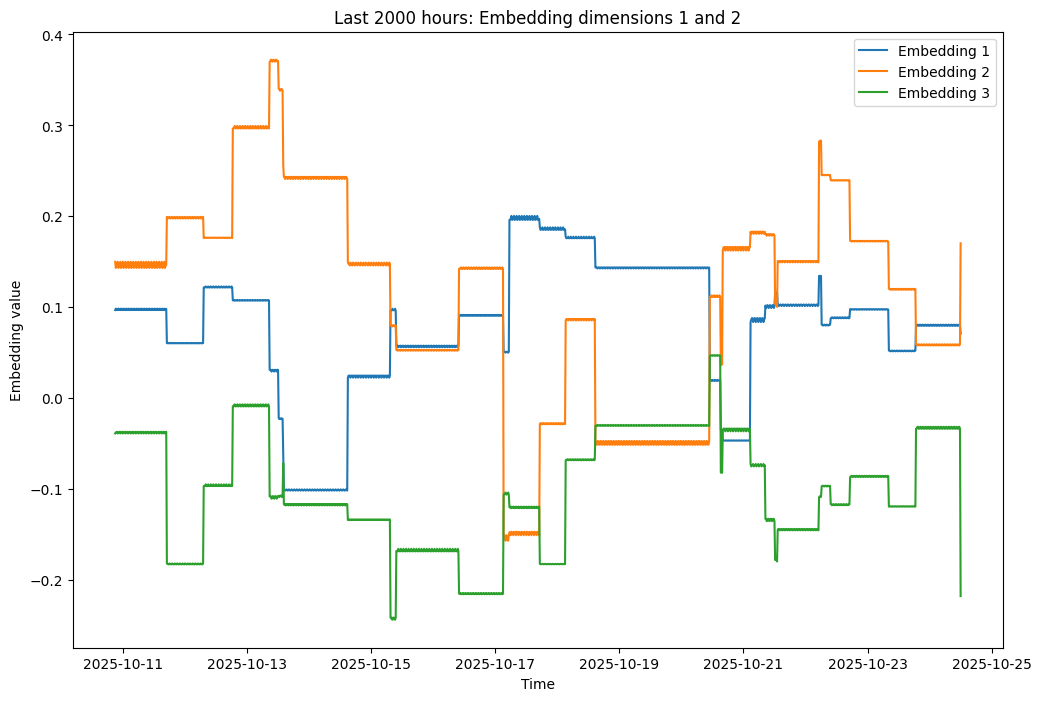

In [18]:
plt.figure(figsize=(12, 8))
last_2000 = weighted_embeddings_array[-2000:] if weighted_embeddings_array.shape[0] > 2000 else weighted_embeddings_array
ts_index = master_df.index[-last_2000.shape[0]:]
for i in range(3):
    plt.plot(ts_index, last_2000[:, i], label=f"Embedding {i+1}")
plt.xlabel("Time")
plt.ylabel("Embedding value")
plt.title("Last 2000 hours: Embedding dimensions 1 and 2")
plt.legend()
plt.show()


In [22]:


# Apply UMAP dimensionality reduction to the time-decayed embeddings
print(f"Applying UMAP to reduce embeddings from {weighted_embeddings_array.shape[1]} to 20 dimensions...")

# Check for NaN values and handle them
nan_mask = np.isnan(weighted_embeddings_array).any(axis=1)
num_nan_rows = nan_mask.sum()
print(f"Found {num_nan_rows} rows with NaN values. Filling with zeros before UMAP...")

# Fill NaN values with zeros for UMAP (preserves array shape and index alignment)
weighted_embeddings_clean = weighted_embeddings_array.copy()
weighted_embeddings_clean[nan_mask] = 0.0

# Removed random_state to enable full parallelism with n_jobs=-1
reducer = umap.UMAP(n_components=20, n_jobs=-1, verbose=False)
reduced_embeddings = reducer.fit_transform(weighted_embeddings_clean)

# Create DataFrame with reduced embeddings
td_embeddings_df = pd.DataFrame(
    reduced_embeddings,
    index=master_df.index,
    columns=[f'embedding_dim_{i}' for i in range(20)]
)

print(f"Output shape: {td_embeddings_df.shape}")


Applying UMAP to reduce embeddings from 384 to 20 dimensions...
Found 691 rows with NaN values. Filling with zeros before UMAP...
Output shape: (9339, 20)


In [23]:
print(td_embeddings_df.shape)
td_embeddings_df.head(5)

(9339, 20)


,embedding_dim_0,embedding_dim_1,embedding_dim_2,embedding_dim_3,embedding_dim_4,embedding_dim_5,embedding_dim_6,embedding_dim_7,embedding_dim_8,embedding_dim_9,embedding_dim_10,embedding_dim_11,embedding_dim_12,embedding_dim_13,embedding_dim_14,embedding_dim_15,embedding_dim_16,embedding_dim_17,embedding_dim_18,embedding_dim_19
2025-01-07 23:00:00,0.388040,6.899367,5.983735,4.128004,2.472359,3.747172,-0.274789,2.826942,1.280402,1.971864,1.651018,4.511956,8.996271,6.965156,6.943141,3.267505,4.321090,1.267500,0.255746,3.248725
2025-01-08 00:00:00,0.359417,6.929332,5.955953,4.098999,2.500731,3.775910,-0.247294,2.797720,1.250515,1.999921,1.679318,4.540863,8.968698,6.937062,6.915439,3.238786,4.291334,1.295177,0.225050,3.275874
2025-01-08 01:00:00,0.365369,6.923111,5.961325,4.104906,2.494700,3.770155,-0.251928,2.804215,1.256862,1.994395,1.673722,4.534833,8.974257,6.942850,6.920928,3.245292,4.297434,1.289883,0.231925,3.270772
2025-01-08 02:00:00,0.363618,6.925245,5.960286,4.103192,2.496514,3.771698,-0.251853,2.801774,1.254552,1.995544,1.674988,4.536704,8.973085,6.941379,6.919785,3.242868,4.295497,1.290760,0.228968,3.271449
2025-01-08 03:00:00,0.347153,6.941715,5.943831,4.086725,2.512969,3.788159,-0.235379,2.785311,1.238096,2.012002,1.691446,4.553168,8.956615,6.924924,6.903325,3.226416,4.279035,1.307234,0.212523,3.287933


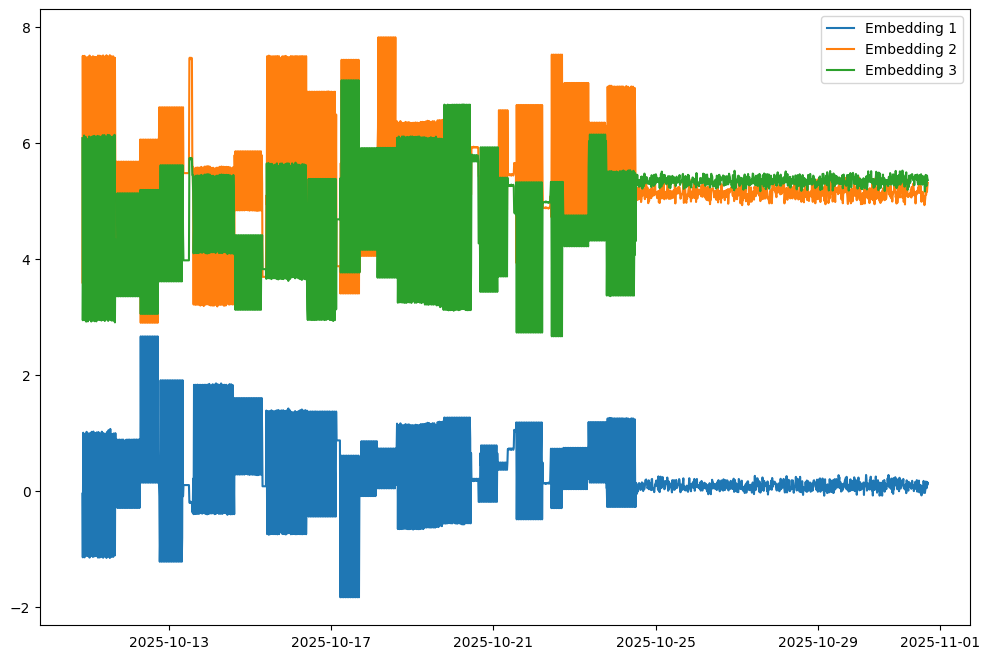

In [24]:
# Only plot the last 2000 hours for the first 5 embeddings to ensure smooth decay

plt.figure(figsize=(12, 8))
plot_df = td_embeddings_df.tail(2000)
for i in range(3):
    plt.plot(plot_df.index, plot_df[plot_df.columns[i]], label=f'Embedding {i+1}')
plt.legend()
plt.show()

now we merge all the features together

In [25]:
# Store default merged_df for baseline comparison
merged_df_default = master_df.join([td_topics_df, td_embeddings_df], how='left')
print(merged_df_default.shape)
merged_df_default.head(5)

(9339, 42)


,price,total_power,target,price_lag_24,price_lag_168,total_power_lag_24,total_power_lag_168,hour,week_of_year,month,...,embedding_dim_10,embedding_dim_11,embedding_dim_12,embedding_dim_13,embedding_dim_14,embedding_dim_15,embedding_dim_16,embedding_dim_17,embedding_dim_18,embedding_dim_19
2025-01-07 23:00:00,71.05,131382.6,101.44,19.07,2.16,113247.3,113506.4,23,2,1,...,1.651018,4.511956,8.996271,6.965156,6.943141,3.267505,4.321090,1.267500,0.255746,3.248725
2025-01-08 00:00:00,68.01,126774.1,100.00,8.71,1.60,110138.0,109574.1,0,2,1,...,1.679318,4.540863,8.968698,6.937062,6.915439,3.238786,4.291334,1.295177,0.225050,3.275874
2025-01-08 01:00:00,63.34,124274.4,98.77,8.90,0.00,105867.7,107039.7,1,2,1,...,1.673722,4.534833,8.974257,6.942850,6.920928,3.245292,4.297434,1.289883,0.231925,3.270772
2025-01-08 02:00:00,57.01,126855.3,95.22,5.01,-0.01,105542.6,105082.2,2,2,1,...,1.674988,4.536704,8.973085,6.941379,6.919785,3.242868,4.295497,1.290760,0.228968,3.271449
2025-01-08 03:00:00,66.29,130570.5,98.28,5.13,-0.01,108462.1,101609.3,3,2,1,...,1.691446,4.553168,8.956615,6.924924,6.903325,3.226416,4.279035,1.307234,0.212523,3.287933


---
# Grid Search for Time-Decayed Parameters
This section performs a grid search to find optimal time-decayed parameters (`lookback_window` and `decay_lambda`) using Ridge Regression for fast exploration. We'll precompute features for all parameter combinations, then use a simplified expanding window for grid search.


In [26]:
# Define parameter grid for grid search
lookback_windows = [168, 336, 504, 672]  # 1, 2, 3, 4 weeks in hours
decay_lambdas = [0.01, 0.02, 0.05, 0.1, 0.2]

# Create all combinations
param_combinations = []
for lw in lookback_windows:
    for dl in decay_lambdas:
        param_combinations.append({'lookback_window': lw, 'decay_lambda': dl})

print(f"Total parameter combinations: {len(param_combinations)}")
print(f"Lookback windows: {lookback_windows}")
print(f"Decay lambdas: {decay_lambdas}")
print(f"\nFirst 3 combinations (showing sample):")
for i, combo in enumerate(param_combinations[:3], 1):
    print(f"{i}. lookback_window={combo['lookback_window']}h, decay_lambda={combo['decay_lambda']}")


Total parameter combinations: 20
Lookback windows: [168, 336, 504, 672]
Decay lambdas: [0.01, 0.02, 0.05, 0.1, 0.2]

First 3 combinations (showing sample):
1. lookback_window=168h, decay_lambda=0.01
2. lookback_window=168h, decay_lambda=0.02
3. lookback_window=168h, decay_lambda=0.05


In [29]:
def precompute_single_combination(params):
    """Helper function to precompute features for a single parameter combination."""
    lw = params['lookback_window']
    dl = params['decay_lambda']
    
    # Compute topic counts
    td_topics = compute_time_decayed_topic_counts(news_df, master_df, lookback_window=lw, decay_lambda=dl, verbose=False)
    
    # Compute embeddings
    weighted_embeddings = compute_time_decayed_embeddings(news_df, master_df, lookback_window=lw, decay_lambda=dl, verbose=False)
    
    # Handle NaN values before PCA (PCA doesn't accept NaN)
    nan_mask = np.isnan(weighted_embeddings).any(axis=1)
    weighted_embeddings_clean = weighted_embeddings.copy()
    weighted_embeddings_clean[nan_mask] = 0.0
    
    # Replace UMAP with PCA for faster dimensionality reduction
    reducer = PCA(n_components=20)
    reduced_embeddings = reducer.fit_transform(weighted_embeddings_clean)
    
    td_embeddings = pd.DataFrame(
        reduced_embeddings,
        index=master_df.index,
        columns=[f'embedding_dim_{i}' for i in range(20)]
    )
    
    return (lw, dl), (td_topics, td_embeddings)

In [30]:
# Precompute features for all parameter combinations
# This will compute time-decayed topics and embeddings for each combination
print(f"Precomputing features for {len(param_combinations)} parameter combinations...")
print("This may take a while, but will speed up the grid search significantly...\n")

# Use parallel processing to precompute features
precomputed_features = dict(
    Parallel(n_jobs=-1, verbose=10)(
        delayed(precompute_single_combination)(params)
        for params in param_combinations
    )
)

print(f"\nPrecomputation complete! Features computed for {len(precomputed_features)} parameter combinations.")
print(f"Sample keys: {list(precomputed_features.keys())[:3]}")

Precomputing features for 20 parameter combinations...
This may take a while, but will speed up the grid search significantly...



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
Processing timestamps: 100%|██████████| 9339/9339 [00:00<00:00, 12476.34it/s]
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    3.4s
Processing timestamps: 100%|██████████| 9339/9339 [00:00<00:00, 24557.91it/s]



Precomputation complete! Features computed for 20 parameter combinations.
Sample keys: [(168, 0.01), (168, 0.02), (168, 0.05)]


[Parallel(n_jobs=-1)]: Done  17 out of  20 | elapsed:    5.0s remaining:    0.9s
[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:    5.1s finished


In [31]:
# Merge and split all 20 precomputed datasets
# This eliminates redundant merging and splitting operations later
print("Merging and splitting all 20 precomputed datasets...")
print("This will create 70% train / 20% validation / 10% test splits for each dataset\n")

preprocessed_datasets = {}

for params_key, (td_topics_df, td_embeddings_df) in precomputed_features.items():
    # Step 1: Merge topics and embeddings with master_df ONCE
    merged_features_df = master_df.join([td_topics_df, td_embeddings_df], how='left')
    
    # Step 2: Drop rows with NaN targets ONCE
    model_df = merged_features_df.dropna(subset=['target']).copy()
    
    # Step 3: Split into train (70%), validation (20%), test (10%) ONCE
    train_size = int(len(model_df) * 0.7)
    val_size = int(len(model_df) * 0.2)
    
    train_df = model_df.iloc[:train_size].copy()
    val_df = model_df.iloc[train_size:train_size + val_size].copy()
    test_df = model_df.iloc[train_size + val_size:].copy()
    
    # Get feature columns for later use
    topic_cols = list(td_topics_df.columns)
    embedding_cols = list(td_embeddings_df.columns)
    news_features = topic_cols + embedding_cols
    
    # Store preprocessed data
    preprocessed_datasets[params_key] = {
        'train_df': train_df,
        'val_df': val_df,
        'test_df': test_df,
        'news_features': news_features,
        'topic_cols': topic_cols,
        'embedding_cols': embedding_cols
    }

print(f"Preprocessing complete! Processed {len(preprocessed_datasets)} datasets.")
print(f"Sample dataset sizes for {list(preprocessed_datasets.keys())[0]}:")
sample_key = list(preprocessed_datasets.keys())[0]
sample_data = preprocessed_datasets[sample_key]
print(f"  Train: {len(sample_data['train_df'])} samples")
print(f"  Validation: {len(sample_data['val_df'])} samples")
print(f"  Test: {len(sample_data['test_df'])} samples")


Merging and splitting all 20 precomputed datasets...
This will create 70% train / 20% validation / 10% test splits for each dataset

Preprocessing complete! Processed 20 datasets.
Sample dataset sizes for (168, 0.01):
  Train: 6537 samples
  Validation: 1867 samples
  Test: 935 samples


In [32]:
# Pre-scale all 20 preprocessed datasets
# Fit scaler on training set and transform train/validation/test sets
print("Pre-scaling all 20 datasets...")
print("Fitting scaler on training set and transforming all splits\n")

for params_key, data_dict in preprocessed_datasets.items():
    train_df = data_dict['train_df']
    val_df = data_dict['val_df']
    test_df = data_dict['test_df']
    news_features = data_dict['news_features']
    
    # Fit scaler on training set's news features only
    scaler_news = StandardScaler()
    train_news_features = train_df[news_features].fillna(0)
    scaler_news.fit(train_news_features)
    
    # Transform all splits using the fitted scaler
    # We'll create new columns with '_scaled' suffix for the news features
    for df_name, df in [('train_df', train_df), ('val_df', val_df), ('test_df', test_df)]:
        news_data = df[news_features].fillna(0)
        news_scaled = scaler_news.transform(news_data)
        
        # Create scaled column names
        for idx, feat in enumerate(news_features):
            scaled_col = f"{feat}_scaled"
            df[scaled_col] = news_scaled[:, idx]
        
        # Update the dataframe in the dictionary
        data_dict[df_name] = df
    
    # Store the scaler for later use
    data_dict['scaler_news'] = scaler_news
    
    # Store scaled news feature names
    scaled_news_features = [f"{feat}_scaled" for feat in news_features]
    data_dict['scaled_news_features'] = scaled_news_features

print("Scaling complete! All datasets have been scaled.")
# Get sample scaled feature count from first dataset
sample_key = list(preprocessed_datasets.keys())[0]
sample_scaled_features = preprocessed_datasets[sample_key]['scaled_news_features']
print(f"Scaled news features created: {len(sample_scaled_features)} features per dataset")


Pre-scaling all 20 datasets...
Fitting scaler on training set and transforming all splits

Scaling complete! All datasets have been scaled.
Scaled news features created: 30 features per dataset


In [33]:
def evaluate_single_parameter_combination(params_key, train_df, val_df, baseline_features, 
                                          scaled_news_features, retrain_frequency=168):
    """
    Evaluate a single parameter combination using Ridge Regression with simplified expanding window.
    This function is designed to be parallelized.
    
    Parameters:
        params_key: tuple of (lookback_window, decay_lambda)
        train_df: Pre-processed training DataFrame (already merged, split, and scaled)
        val_df: Pre-processed validation DataFrame (already merged, split, and scaled)
        baseline_features: list of baseline feature names
        scaled_news_features: list of scaled news feature column names
        retrain_frequency: Hours between retraining (default: 168 for simplified grid search)
    
    Returns:
        Dictionary with metrics and parameter info
    """
    lw, dl = params_key
    
    # Simplified expanding window: retrain every retrain_frequency hours
    last_retrain_idx = 0
    all_val_predictions = []
    all_val_actuals = []
    
    # Combine train and val to simulate expanding window
    # For each validation point, we expand the training set up to that point
    for i in range(len(val_df)):
        # Current training window: all training data + validation data up to current point
        train_end_idx = len(train_df) + i
        
        # Get expanded training data (train + val up to current point)
        if i == 0:
            current_expanded_train = train_df.copy()
        else:
            current_expanded_train = pd.concat([
                train_df,
                val_df.iloc[:i]
            ])
        
        # Check if we need to retrain
        if i == 0 or (i - last_retrain_idx) >= retrain_frequency:
            # Prepare features using pre-scaled news features
            X_train_advanced = np.column_stack([
                current_expanded_train[baseline_features].fillna(0).values,
                current_expanded_train[scaled_news_features].fillna(0).values
            ])
            
            y_train = current_expanded_train['target'].values
            
            # Train Ridge Regression model
            ridge_model = Ridge(alpha=1.0, random_state=42)
            ridge_model.fit(X_train_advanced, y_train)
            
            last_retrain_idx = i
            
            # Store model for predictions
            stored_model = ridge_model
        
        # Make prediction on current validation point
        val_point = val_df.iloc[i:i+1]
        X_val_advanced = np.column_stack([
            val_point[baseline_features].fillna(0).values,
            val_point[scaled_news_features].fillna(0).values
        ])
        
        y_val_pred = stored_model.predict(X_val_advanced)[0]
        y_val_actual = val_point['target'].values[0]
        
        all_val_predictions.append(y_val_pred)
        all_val_actuals.append(y_val_actual)
    
    # Calculate metrics
    if len(all_val_predictions) > 0:
        mae = mean_absolute_error(all_val_actuals, all_val_predictions)
        rmse = np.sqrt(mean_squared_error(all_val_actuals, all_val_predictions))
        
        return {
            'lookback_window': lw,
            'decay_lambda': dl,
            'mae': mae,
            'rmse': rmse,
            'params_key': params_key
        }
    else:
        return {
            'lookback_window': lw,
            'decay_lambda': dl,
            'mae': np.inf,
            'rmse': np.inf,
            'params_key': params_key
        }


def grid_search_time_decay_params(preprocessed_datasets, baseline_features, retrain_frequency=168):
    """
    Grid search using Ridge Regression with simplified expanding window.
    Now parallelized using joblib for GPU cluster optimization.
    
    Parameters:
        preprocessed_datasets: dict of {(lookback_window, decay_lambda): {train_df, val_df, test_df, scaled_news_features, ...}}
        baseline_features: list of baseline feature names
        retrain_frequency: Hours between retraining (default: 168 for simplified grid search)
    
    Returns:
        List of top 5 parameter combinations with metrics, sorted by validation MAE
    """
    print(f"Grid searching {len(preprocessed_datasets)} parameter combinations...")
    print(f"Using Ridge Regression with retraining every {retrain_frequency} hours")
    print(f"Parallelizing evaluation across parameter combinations using joblib...\n")
    
    # Parallelize evaluation across all parameter combinations
    results = Parallel(n_jobs=-1, verbose=10)(
        delayed(evaluate_single_parameter_combination)(
            params_key,
            data_dict['train_df'],
            data_dict['val_df'],
            baseline_features,
            data_dict['scaled_news_features'],
            retrain_frequency
        )
        for params_key, data_dict in preprocessed_datasets.items()
    )
    
    # Sort by MAE (ascending - lower is better)
    results_sorted = sorted(results, key=lambda x: x['mae'])
    
    # Print results summary
    print(f"\n{'='*80}")
    print("TOP 5 PARAMETER COMBINATIONS:")
    print(f"{'='*80}")
    top_5 = results_sorted[:5]
    for i, result in enumerate(top_5, 1):
        print(f"{i}. lookback_window={result['lookback_window']}h, decay_lambda={result['decay_lambda']} | "
              f"MAE={result['mae']:.2f}, RMSE={result['rmse']:.2f}")
    
    return top_5


In [34]:
# Define baseline features (will be used for all combinations)
# Note: Data splitting is now done in the preprocessing step (Cells 33-34)
baseline_features = [
    'price_lag_24', 'price_lag_168', 
    'total_power_lag_24', 'total_power_lag_168',
    'hour', 'month', 'day_of_week', 'day_of_year', 'week_of_year'
]

print("Baseline features defined:")
print(baseline_features)


Baseline features defined:
['price_lag_24', 'price_lag_168', 'total_power_lag_24', 'total_power_lag_168', 'hour', 'month', 'day_of_week', 'day_of_year', 'week_of_year']


In [35]:
# Run grid search to find top 5 parameter combinations
top_5_combinations = grid_search_time_decay_params(
    preprocessed_datasets=preprocessed_datasets,
    baseline_features=baseline_features,
    retrain_frequency=168  # Simplified: retrain every 168 hours (1 week)
)


Grid searching 20 parameter combinations...
Using Ridge Regression with retraining every 168 hours
Parallelizing evaluation across parameter combinations using joblib...



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done   8 out of  20 | elapsed:    5.1s remaining:    7.7s
[Parallel(n_jobs=-1)]: Done  11 out of  20 | elapsed:    9.2s remaining:    7.5s
[Parallel(n_jobs=-1)]: Done  14 out of  20 | elapsed:    9.5s remaining:    4.1s



TOP 5 PARAMETER COMBINATIONS:
1. lookback_window=504h, decay_lambda=0.05 | MAE=26.43, RMSE=44.36
2. lookback_window=672h, decay_lambda=0.05 | MAE=26.43, RMSE=44.36
3. lookback_window=336h, decay_lambda=0.05 | MAE=26.43, RMSE=44.36
4. lookback_window=168h, decay_lambda=0.05 | MAE=26.48, RMSE=44.41
5. lookback_window=672h, decay_lambda=0.1 | MAE=28.35, RMSE=45.46


[Parallel(n_jobs=-1)]: Done  17 out of  20 | elapsed:   12.2s remaining:    2.1s
[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:   12.4s finished


---
# Training Full Models on Top 5 Combinations
Now we train the full models (XGBoost and Linear Regression) on the top 5 parameter combinations using the full expanding window approach (retrain every 24 hours).


In [36]:
def train_full_models_on_combination(params_key, train_df, val_df, baseline_features,
                                      scaled_news_features, retrain_frequency=24, verbose=True):
    """
    Train full models (XGBoost and Linear Regression) on a specific parameter combination
    using full expanding window (retrain every 24 hours).
    
    Parameters:
        params_key: tuple of (lookback_window, decay_lambda)
        train_df: Pre-processed training DataFrame (already merged, split, and scaled)
        val_df: Pre-processed validation DataFrame (already merged, split, and scaled)
        baseline_features: list of baseline feature names
        scaled_news_features: list of scaled news feature column names
        retrain_frequency: Hours between retraining (default: 24 for full training)
        verbose: Whether to print progress messages (default: True)
    
    Returns:
        Dictionary with models, predictions, and metrics
    """
    lw, dl = params_key
    
    # Expanding window training: retrain every retrain_frequency hours
    last_retrain_idx = 0
    all_val_predictions = {'lr_baseline': [], 'lr_advanced': [], 'xgb_baseline': [], 'xgb_advanced': []}
    all_val_actuals = []
    
    models = {'lr_baseline': None, 'lr_advanced': None, 'xgb_baseline': None, 'xgb_advanced': None}
    
    if verbose:
        print(f"Training full models for lookback_window={lw}h, decay_lambda={dl}...")
    
    # Use tqdm only if verbose, otherwise disable it
    val_iterator = tqdm(range(len(val_df)), desc=f"Expanding window (full training)", leave=False, disable=not verbose)
    
    for i in val_iterator:
        # Get expanded training data (train + val up to current point)
        if i == 0:
            current_expanded_train = train_df.copy()
        else:
            current_expanded_train = pd.concat([
                train_df,
                val_df.iloc[:i]
            ])
        
        # Check if we need to retrain
        if i == 0 or (i - last_retrain_idx) >= retrain_frequency:
            # Prepare baseline features (no news features)
            X_train_baseline = current_expanded_train[baseline_features].fillna(0).values
            
            # Prepare advanced features using pre-scaled news features
            X_train_advanced = np.column_stack([
                current_expanded_train[baseline_features].fillna(0).values,
                current_expanded_train[scaled_news_features].fillna(0).values
            ])
            
            y_train = current_expanded_train['target'].values
            
            # Train baseline models
            models['lr_baseline'] = LinearRegression()
            models['lr_baseline'].fit(X_train_baseline, y_train)
            
            models['xgb_baseline'] = XGBRegressor(
                n_estimators=100,
                max_depth=5,
                learning_rate=0.1,
                random_state=42,
                n_jobs=-1,
                verbosity=0
            )
            models['xgb_baseline'].fit(X_train_baseline, y_train)
            
            # Train advanced models
            models['lr_advanced'] = LinearRegression()
            models['lr_advanced'].fit(X_train_advanced, y_train)
            
            models['xgb_advanced'] = XGBRegressor(
                n_estimators=100,
                max_depth=5,
                learning_rate=0.1,
                random_state=42,
                n_jobs=-1,
                verbosity=0
            )
            models['xgb_advanced'].fit(X_train_advanced, y_train)
            
            last_retrain_idx = i
        
        # Make predictions on current validation point
        val_point = val_df.iloc[i:i+1]
        X_val_baseline = val_point[baseline_features].fillna(0).values
        X_val_advanced = np.column_stack([
            val_point[baseline_features].fillna(0).values,
            val_point[scaled_news_features].fillna(0).values
        ])
        
        y_val_actual = val_point['target'].values[0]
        all_val_actuals.append(y_val_actual)
        
        # Make predictions for all models
        all_val_predictions['lr_baseline'].append(models['lr_baseline'].predict(X_val_baseline)[0])
        all_val_predictions['xgb_baseline'].append(models['xgb_baseline'].predict(X_val_baseline)[0])
        all_val_predictions['lr_advanced'].append(models['lr_advanced'].predict(X_val_advanced)[0])
        all_val_predictions['xgb_advanced'].append(models['xgb_advanced'].predict(X_val_advanced)[0])
    
    # Calculate metrics for all models
    metrics = {}
    for model_name in ['lr_baseline', 'lr_advanced', 'xgb_baseline', 'xgb_advanced']:
        if len(all_val_predictions[model_name]) > 0:
            mae = mean_absolute_error(all_val_actuals, all_val_predictions[model_name])
            rmse = np.sqrt(mean_squared_error(all_val_actuals, all_val_predictions[model_name]))
            metrics[model_name] = {'mae': mae, 'rmse': rmse}
        else:
            metrics[model_name] = {'mae': np.inf, 'rmse': np.inf}
    
    return {
        'params_key': params_key,
        'lookback_window': lw,
        'decay_lambda': dl,
        'predictions': all_val_predictions,
        'actuals': all_val_actuals,
        'metrics': metrics
    }

In [37]:
from joblib import Parallel, delayed

def train_single_combination(combo, preprocessed_datasets, baseline_features):
    """Wrapper function for parallel execution"""
    params_key = combo['params_key']
    data_dict = preprocessed_datasets[params_key]
    
    result = train_full_models_on_combination(
        params_key=params_key,
        train_df=data_dict['train_df'],
        val_df=data_dict['val_df'],
        baseline_features=baseline_features,
        scaled_news_features=data_dict['scaled_news_features'],
        retrain_frequency=24,
        verbose=False
    )
    return result

# Train full models on top 5 combinations in parallel
print(f"Training full models on {len(top_5_combinations)} combinations in parallel...")
top_5_results = Parallel(n_jobs=-1, verbose=10)(
    delayed(train_single_combination)(
        combo, preprocessed_datasets, baseline_features
    )
    for combo in top_5_combinations
)

print(f"\nCompleted training on top {len(top_5_results)} combinations")

Training full models on 5 combinations in parallel...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   34.7s remaining:   52.1s



Completed training on top 5 combinations


[Parallel(n_jobs=-1)]: Done   3 out of   5 | elapsed:   35.0s remaining:   23.4s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   35.2s finished


In [38]:
# Evaluate top 5 combinations on validation set and select best
print(f"\n{'='*80}")
print("VALIDATION SET PERFORMANCE - TOP 5 COMBINATIONS:")
print(f"{'='*80}")
print(f"{'Rank':<6} {'Lookback':<12} {'Decay Lambda':<15} {'LR-Base MAE':<12} {'LR-Adv MAE':<12} {'XGB-Base MAE':<12} {'XGB-Adv MAE':<12}")
print("-"*80)

# Sort by XGBoost Advanced MAE (best model)
top_5_results_sorted = sorted(top_5_results, key=lambda x: x['metrics']['xgb_advanced']['mae'])

for i, result in enumerate(top_5_results_sorted, 1):
    print(f"{i:<6} {result['lookback_window']:<12} {result['decay_lambda']:<15.2f} "
          f"{result['metrics']['lr_baseline']['mae']:<12.2f} "
          f"{result['metrics']['lr_advanced']['mae']:<12.2f} "
          f"{result['metrics']['xgb_baseline']['mae']:<12.2f} "
          f"{result['metrics']['xgb_advanced']['mae']:<12.2f}")

# Select best combination (lowest XGBoost Advanced MAE)
best_result = top_5_results_sorted[0]
best_params = best_result['params_key']

print(f"\n{'='*80}")
print(f"BEST PARAMETER COMBINATION (based on XGBoost Advanced validation MAE):")
print(f"  lookback_window: {best_result['lookback_window']}h")
print(f"  decay_lambda: {best_result['decay_lambda']}")
print(f"  XGBoost Advanced Validation MAE: {best_result['metrics']['xgb_advanced']['mae']:.2f}")
print(f"  XGBoost Advanced Validation RMSE: {best_result['metrics']['xgb_advanced']['rmse']:.2f}")
print(f"{'='*80}")



VALIDATION SET PERFORMANCE - TOP 5 COMBINATIONS:
Rank   Lookback     Decay Lambda    LR-Base MAE  LR-Adv MAE   XGB-Base MAE XGB-Adv MAE 
--------------------------------------------------------------------------------
1      168          0.05            27.83        24.57        25.32        26.81       
2      672          0.10            27.83        26.18        25.32        26.92       
3      336          0.05            27.83        24.54        25.32        27.04       
4      672          0.05            27.83        24.54        25.32        27.17       
5      504          0.05            27.83        24.54        25.32        27.23       

BEST PARAMETER COMBINATION (based on XGBoost Advanced validation MAE):
  lookback_window: 168h
  decay_lambda: 0.05
  XGBoost Advanced Validation MAE: 26.81
  XGBoost Advanced Validation RMSE: 41.32


---
# Final Evaluation on Test Set
Retrain the best model on the full training set and evaluate on the test set (to prevent data leakage).


In [39]:
# Retrain final best model on full training set and evaluate on test set
best_lw, best_dl = best_params
best_data_dict = preprocessed_datasets[best_params]

print(f"Retraining final best model on full training set...")
print(f"Parameters: lookback_window={best_lw}h, decay_lambda={best_dl}")

# Use pre-processed datasets (already merged, split, and scaled)
train_df_best = best_data_dict['train_df']
test_df_best = best_data_dict['test_df']
scaled_news_features_best = best_data_dict['scaled_news_features']

# Prepare features using pre-scaled data
X_train_baseline = train_df_best[baseline_features].fillna(0).values
X_train_advanced = np.column_stack([
    train_df_best[baseline_features].fillna(0).values,
    train_df_best[scaled_news_features_best].fillna(0).values
])
y_train = train_df_best['target'].values

# Train final models on full training set (all 4 models)
final_models_best = {
    'lr_baseline': LinearRegression(),
    'lr_advanced': LinearRegression(),
    'xgb_baseline': XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ),
    'xgb_advanced': XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
}

# Train baseline models
final_models_best['lr_baseline'].fit(X_train_baseline, y_train)
final_models_best['xgb_baseline'].fit(X_train_baseline, y_train)

# Train advanced models
final_models_best['lr_advanced'].fit(X_train_advanced, y_train)
final_models_best['xgb_advanced'].fit(X_train_advanced, y_train)

print("Final models trained!")

# Prepare test features using pre-scaled data
X_test_baseline = test_df_best[baseline_features].fillna(0).values
X_test_advanced = np.column_stack([
    test_df_best[baseline_features].fillna(0).values,
    test_df_best[scaled_news_features_best].fillna(0).values
])
y_test = test_df_best['target'].values

# Make predictions for all models
predictions_best = {}
predictions_best['lr_baseline'] = final_models_best['lr_baseline'].predict(X_test_baseline)
predictions_best['xgb_baseline'] = final_models_best['xgb_baseline'].predict(X_test_baseline)
predictions_best['lr_advanced'] = final_models_best['lr_advanced'].predict(X_test_advanced)
predictions_best['xgb_advanced'] = final_models_best['xgb_advanced'].predict(X_test_advanced)

# Calculate metrics for all models
from sklearn.metrics import r2_score
metrics_best = {}
model_names = ['lr_baseline', 'lr_advanced', 'xgb_baseline', 'xgb_advanced']

for model_name in model_names:
    mae = mean_absolute_error(y_test, predictions_best[model_name])
    mse = mean_squared_error(y_test, predictions_best[model_name])
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions_best[model_name])
    metrics_best[model_name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}
    
    print(f"\n{model_name} (Test Set):")
    print(f"  MAE:  {mae:.2f}")
    print(f"  MSE:  {mse:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R²:   {r2:.3f}")

print("\nFinal evaluation completed!")


Retraining final best model on full training set...
Parameters: lookback_window=168h, decay_lambda=0.05
Final models trained!

lr_baseline (Test Set):
  MAE:  32.14
  MSE:  1819.81
  RMSE: 42.66
  R²:   0.236

lr_advanced (Test Set):
  MAE:  34.18
  MSE:  1956.91
  RMSE: 44.24
  R²:   0.178

xgb_baseline (Test Set):
  MAE:  42.01
  MSE:  2986.07
  RMSE: 54.64
  R²:   -0.254

xgb_advanced (Test Set):
  MAE:  43.42
  MSE:  3148.83
  RMSE: 56.11
  R²:   -0.322

Final evaluation completed!


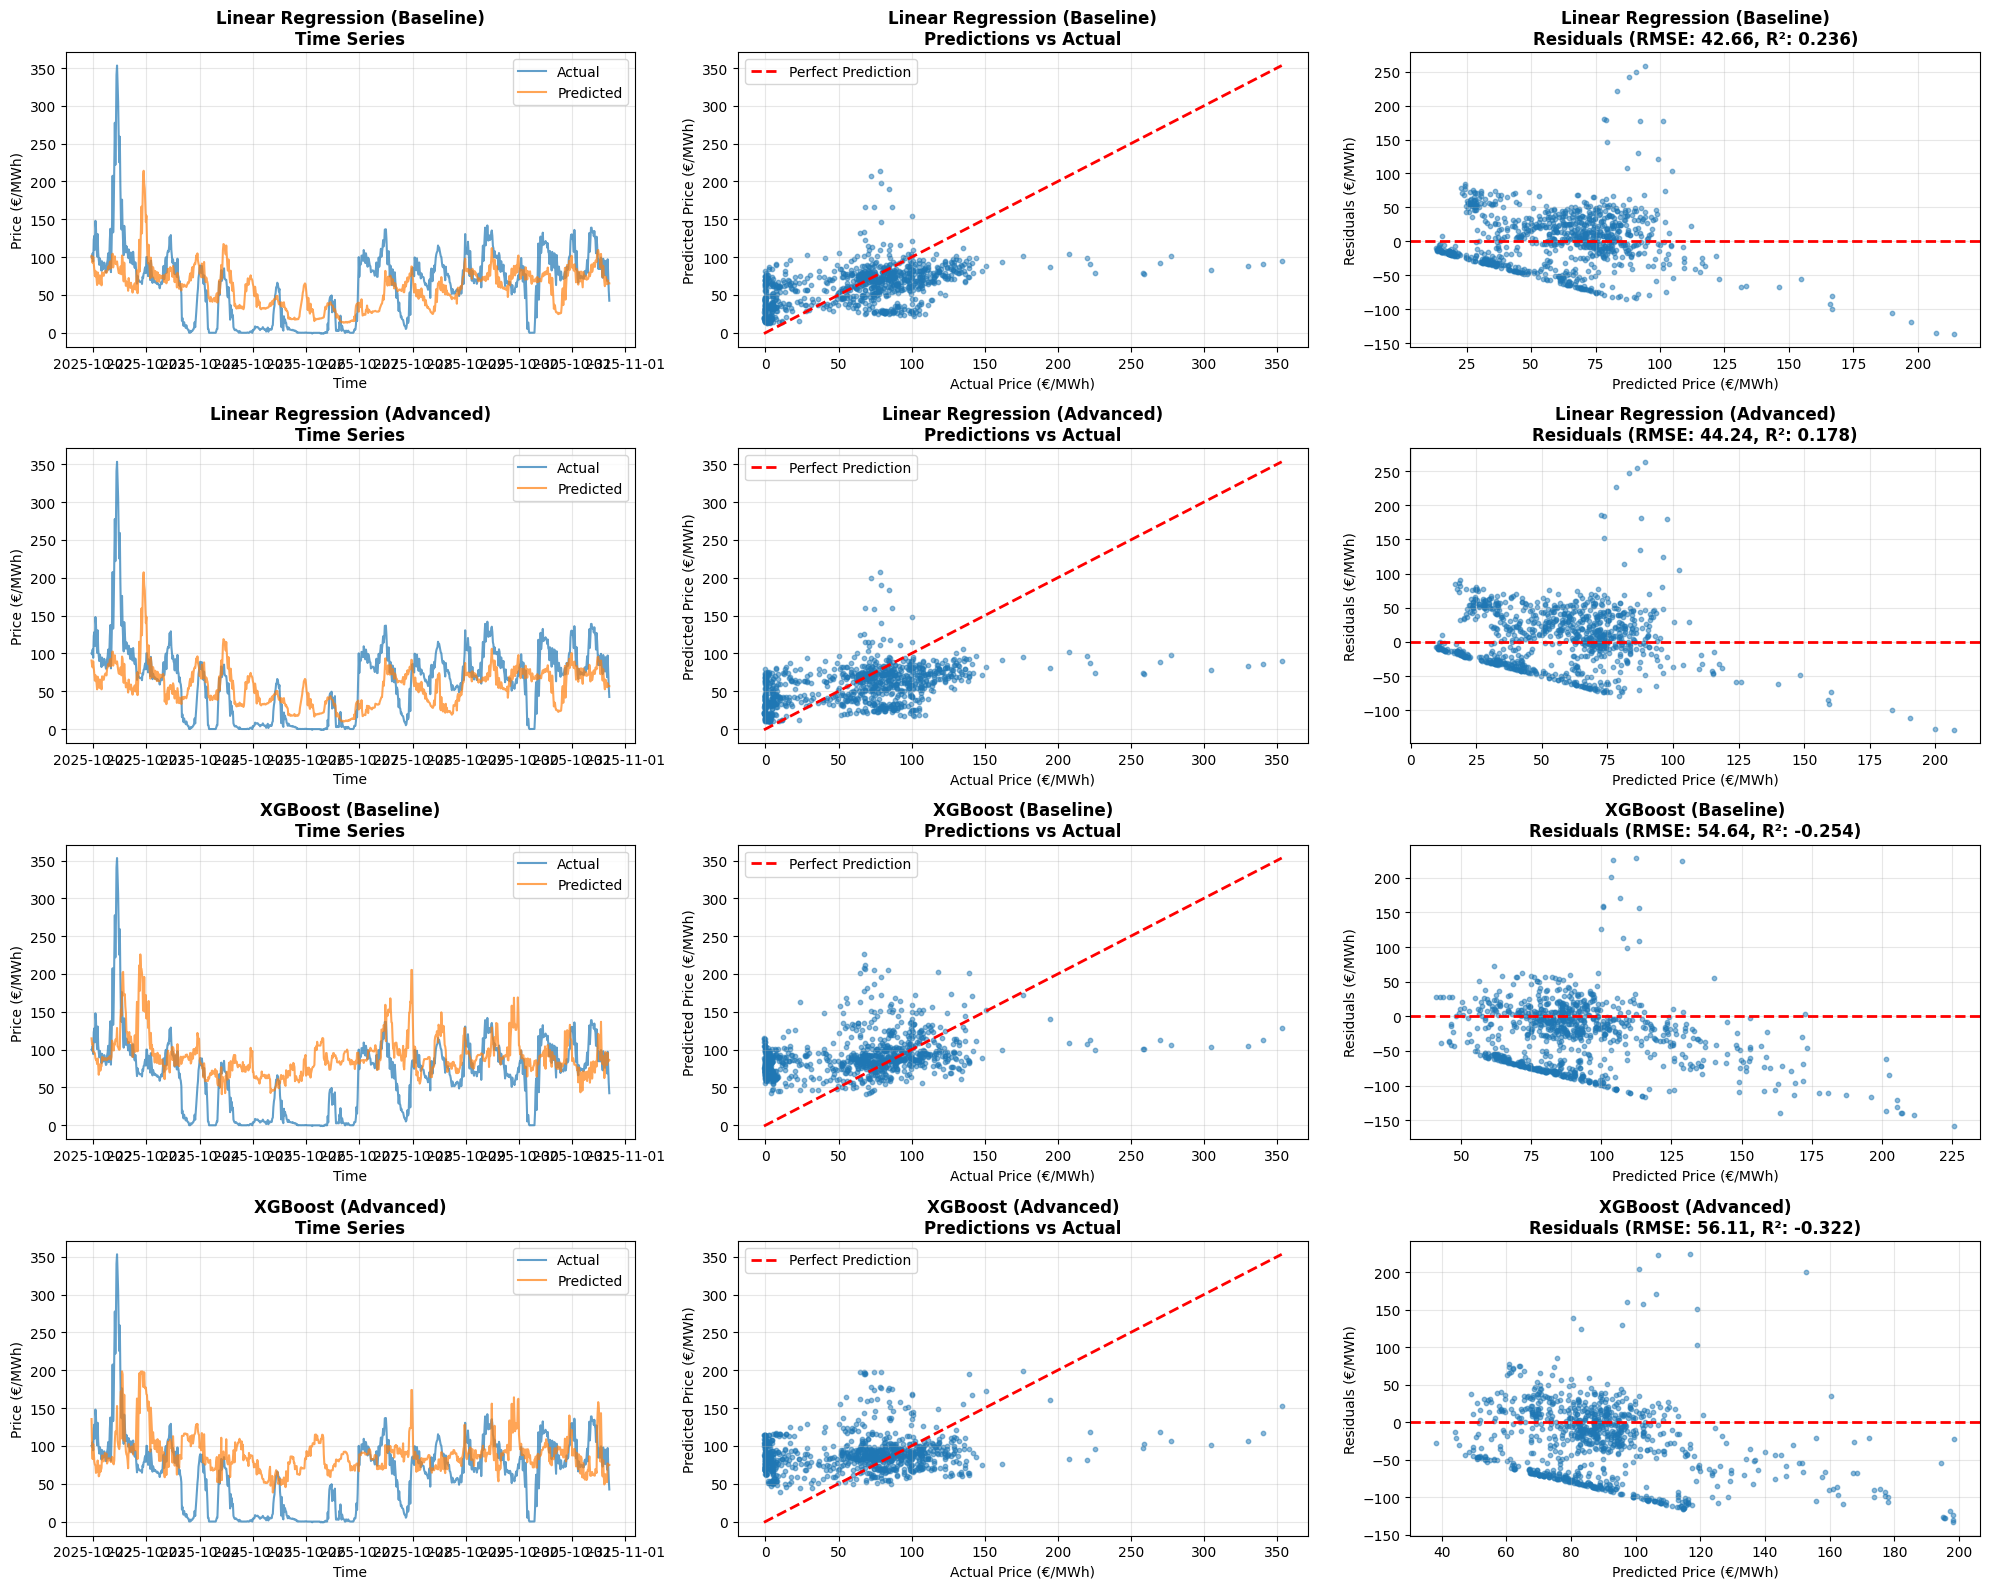

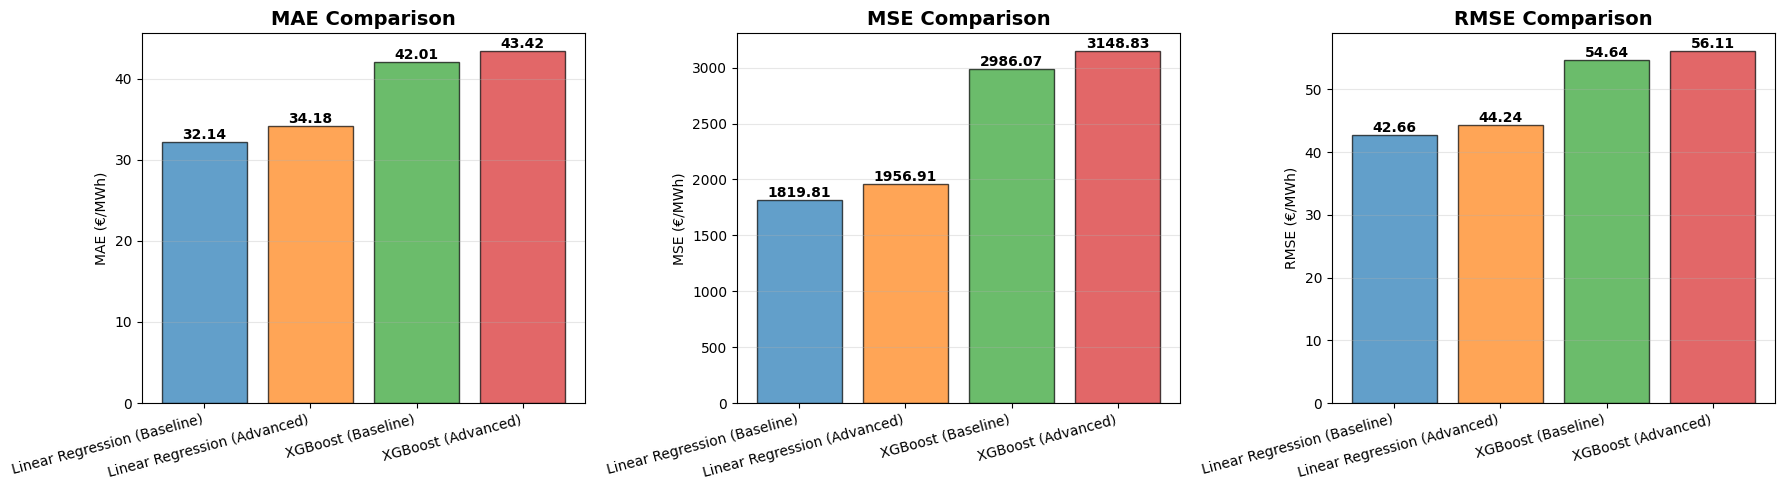

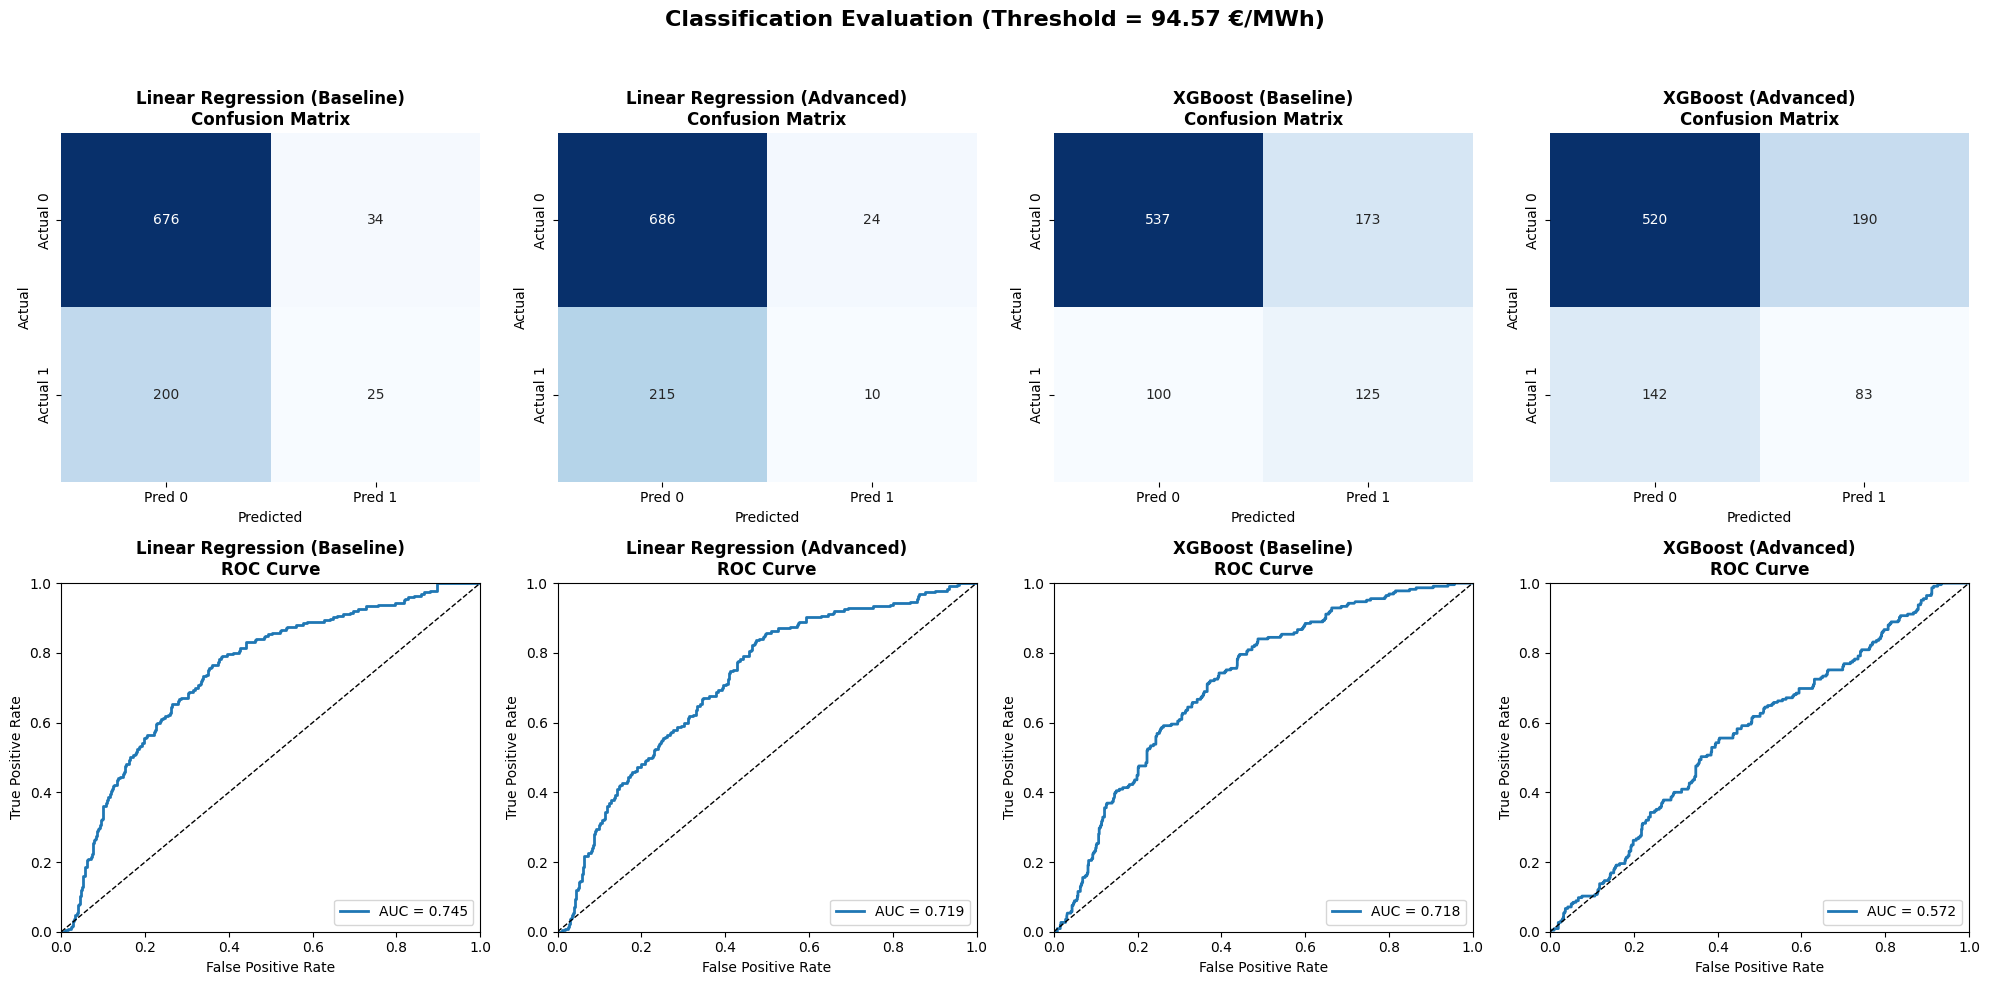


PERFORMANCE SUMMARY
Model                          MAE          MSE          RMSE         R²          
--------------------------------------------------------------------------------
Linear Regression (Baseline)   32.14        1819.81      42.66        0.236       
Linear Regression (Advanced)   34.18        1956.91      44.24        0.178       
XGBoost (Baseline)             42.01        2986.07      54.64        -0.254      
XGBoost (Advanced)             43.42        3148.83      56.11        -0.322      

Classification-style metrics (threshold-based):
Linear Regression (Baseline)   Accuracy: 0.750 AUC: 0.745
Linear Regression (Advanced)   Accuracy: 0.744 AUC: 0.719
XGBoost (Baseline)             Accuracy: 0.708 AUC: 0.718
XGBoost (Advanced)             Accuracy: 0.645 AUC: 0.572


In [42]:
# Create comprehensive performance plots for all models using best parameter combination
from sklearn.metrics import r2_score, confusion_matrix, roc_curve, roc_auc_score

# Align y_test with index for plotting and classification
y_test_series = test_df_best['target']
y_test_array = y_test if isinstance(y_test, np.ndarray) else y_test_series.values

fig = plt.figure(figsize=(20, 16))

# Model names for display
model_display_names = {
    'lr_baseline': 'Linear Regression (Baseline)',
    'lr_advanced': 'Linear Regression (Advanced)',
    'xgb_baseline': 'XGBoost (Baseline)',
    'xgb_advanced': 'XGBoost (Advanced)'
}

model_order = ['lr_baseline', 'lr_advanced', 'xgb_baseline', 'xgb_advanced']

# Create subplots: 4 rows x 3 columns
# Row 1: Predictions vs Actual (time series)
# Row 2: Predictions vs Actual (scatter)
# Row 3: Residuals
# Row 4: Metrics comparison

for idx, model_name in enumerate(model_order):
    row = idx
    
    # Plot 1: Time series - Predictions vs Actual
    ax1 = plt.subplot(4, 3, row * 3 + 1)
    ax1.plot(test_df_best.index, y_test_series, label='Actual', alpha=0.7, linewidth=1.5)
    ax1.plot(test_df_best.index, predictions_best[model_name], label='Predicted', alpha=0.7, linewidth=1.5)
    ax1.set_title(f'{model_display_names[model_name]}\nTime Series', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Price (€/MWh)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Scatter - Predictions vs Actual
    ax2 = plt.subplot(4, 3, row * 3 + 2)
    ax2.scatter(y_test_array, predictions_best[model_name], alpha=0.5, s=10)
    # Add perfect prediction line
    min_val = min(y_test_array.min(), predictions_best[model_name].min())
    max_val = max(y_test_array.max(), predictions_best[model_name].max())
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    ax2.set_title(f'{model_display_names[model_name]}\nPredictions vs Actual', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Actual Price (€/MWh)')
    ax2.set_ylabel('Predicted Price (€/MWh)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Calculate R² for display
    r2 = r2_score(y_test_array, predictions_best[model_name])
    
    # Plot 3: Residuals
    ax3 = plt.subplot(4, 3, row * 3 + 3)
    residuals = y_test_array - predictions_best[model_name]
    ax3.scatter(predictions_best[model_name], residuals, alpha=0.5, s=10)
    ax3.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax3.set_title(
        f'{model_display_names[model_name]}\nResiduals (RMSE: {metrics_best[model_name]["RMSE"]:.2f}, R²: {r2:.3f})',
        fontsize=12,
        fontweight='bold'
    )
    ax3.set_xlabel('Predicted Price (€/MWh)')
    ax3.set_ylabel('Residuals (€/MWh)')
    ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Create a separate figure for metrics comparison
fig2, axes = plt.subplots(1, 3, figsize=(18, 5))

metric_types = ['MAE', 'MSE', 'RMSE']
model_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for metric_idx, metric_type in enumerate(metric_types):
    ax = axes[metric_idx]
    values = [metrics_best[model][metric_type] for model in model_order]
    bars = ax.bar(range(len(model_display_names)), values, color=model_colors, alpha=0.7, edgecolor='black')
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2.0, height, f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
    
    ax.set_xticks(range(len(model_display_names)))
    ax.set_xticklabels([model_display_names[m] for m in model_order], rotation=15, ha='right')
    ax.set_ylabel(f'{metric_type} (€/MWh)')
    ax.set_title(f'{metric_type} Comparison', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Classification-style evaluation using a median threshold
classification_threshold = float(np.median(train_df_best['target']))
y_test_binary = (y_test_array >= classification_threshold).astype(int)
unique_classes = np.unique(y_test_binary)
has_both_classes = unique_classes.size > 1

fig3, axes_cm = plt.subplots(2, len(model_order), figsize=(5 * len(model_order), 10))
classification_metrics = {}

for col, model_name in enumerate(model_order):
    scores = predictions_best[model_name]
    preds_binary = (scores >= classification_threshold).astype(int)
    cm = confusion_matrix(y_test_binary, preds_binary, labels=[0, 1])
    classification_metrics[model_name] = {
        'confusion_matrix': cm,
        'accuracy': float(np.mean(preds_binary == y_test_binary)),
        'auc': None
    }

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['Pred 0', 'Pred 1'],
        yticklabels=['Actual 0', 'Actual 1'],
        ax=axes_cm[0, col]
    )
    axes_cm[0, col].set_title(f'{model_display_names[model_name]}\nConfusion Matrix', fontsize=12, fontweight='bold')
    axes_cm[0, col].set_xlabel('Predicted')
    axes_cm[0, col].set_ylabel('Actual')

    if has_both_classes:
        fpr, tpr, _ = roc_curve(y_test_binary, scores)
        auc_score = roc_auc_score(y_test_binary, scores)
        classification_metrics[model_name]['auc'] = float(auc_score)

        axes_cm[1, col].plot(fpr, tpr, linewidth=2, label=f'AUC = {auc_score:.3f}')
        axes_cm[1, col].plot([0, 1], [0, 1], 'k--', linewidth=1)
        axes_cm[1, col].set_xlim(0, 1)
        axes_cm[1, col].set_ylim(0, 1)
        axes_cm[1, col].set_xlabel('False Positive Rate')
        axes_cm[1, col].set_ylabel('True Positive Rate')
        axes_cm[1, col].set_title(f'{model_display_names[model_name]}\nROC Curve', fontsize=12, fontweight='bold')
        axes_cm[1, col].legend(loc='lower right')
    else:
        axes_cm[1, col].text(
            0.5,
            0.5,
            'Single class in y_test\nROC/AUC undefined',
            ha='center',
            va='center',
            fontsize=11,
            fontweight='bold'
        )
        axes_cm[1, col].set_xlim(0, 1)
        axes_cm[1, col].set_ylim(0, 1)
        axes_cm[1, col].set_xticks([])
        axes_cm[1, col].set_yticks([])
        axes_cm[1, col].set_title(f'{model_display_names[model_name]}\nROC Curve', fontsize=12, fontweight='bold')

fig3.suptitle(
    f'Classification Evaluation (Threshold = {classification_threshold:.2f} €/MWh)',
    fontsize=16,
    fontweight='bold',
    y=0.98
)
fig3.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Print summary table
print("\n" + "=" * 80)
print("PERFORMANCE SUMMARY")
print("=" * 80)
print(f"{'Model':<30} {'MAE':<12} {'MSE':<12} {'RMSE':<12} {'R²':<12}")
print("-" * 80)
for model_name in model_order:
    r2 = r2_score(y_test_array, predictions_best[model_name])
    print(
        f"{model_display_names[model_name]:<30} "
        f"{metrics_best[model_name]['MAE']:<12.2f} "
        f"{metrics_best[model_name]['MSE']:<12.2f} "
        f"{metrics_best[model_name]['RMSE']:<12.2f} "
        f"{r2:<12.3f}"
    )
print("=" * 80)

print("\nClassification-style metrics (threshold-based):")
for model_name in model_order:
    metrics_out = classification_metrics[model_name]
    auc_display = f"{metrics_out['auc']:.3f}" if metrics_out['auc'] is not None else 'N/A'
    print(
        f"{model_display_names[model_name]:<30} "
        f"Accuracy: {metrics_out['accuracy']:.3f} "
        f"AUC: {auc_display}"
    )


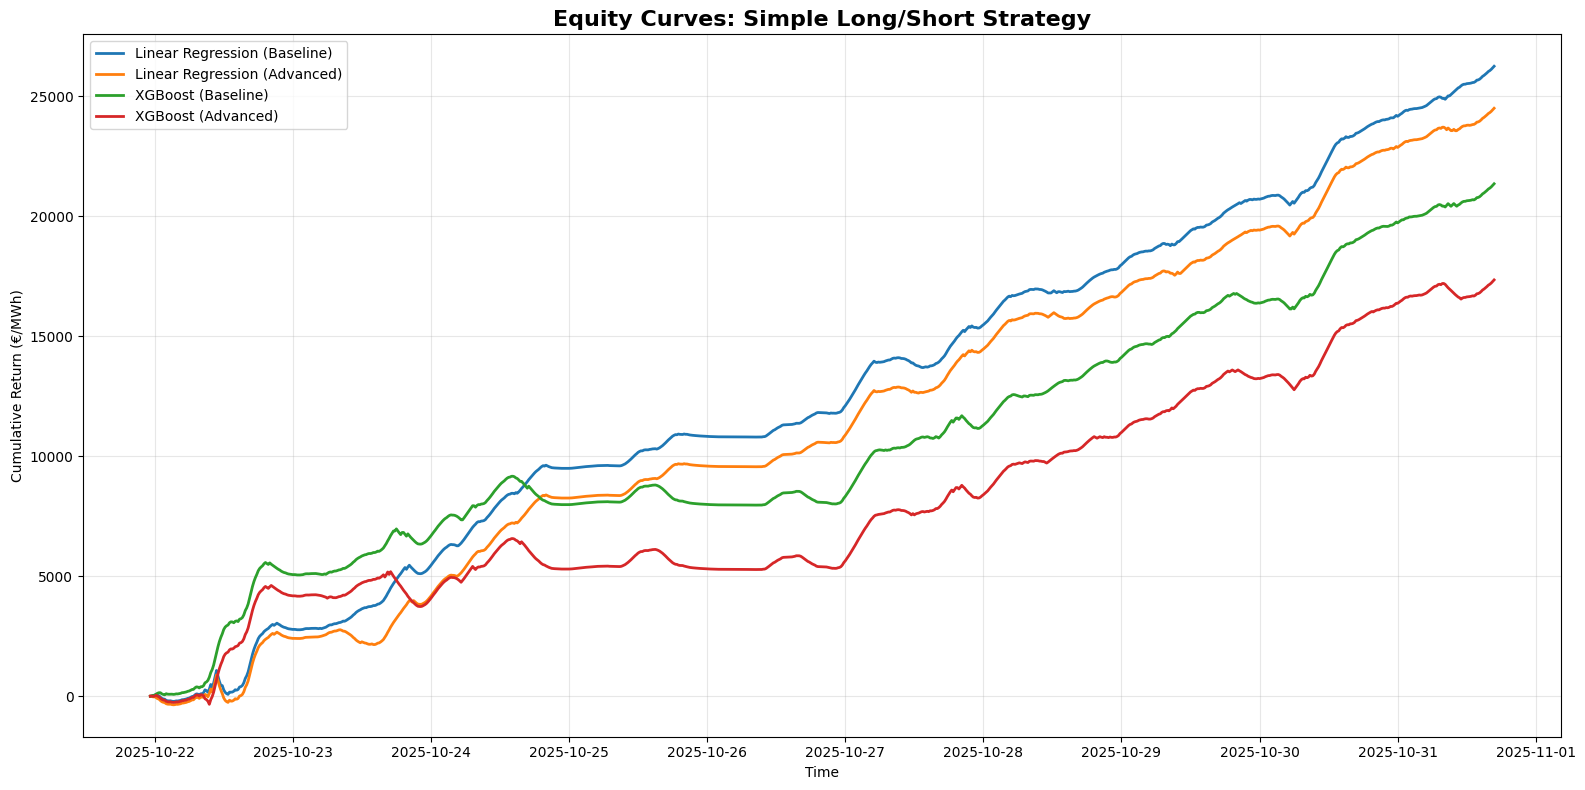

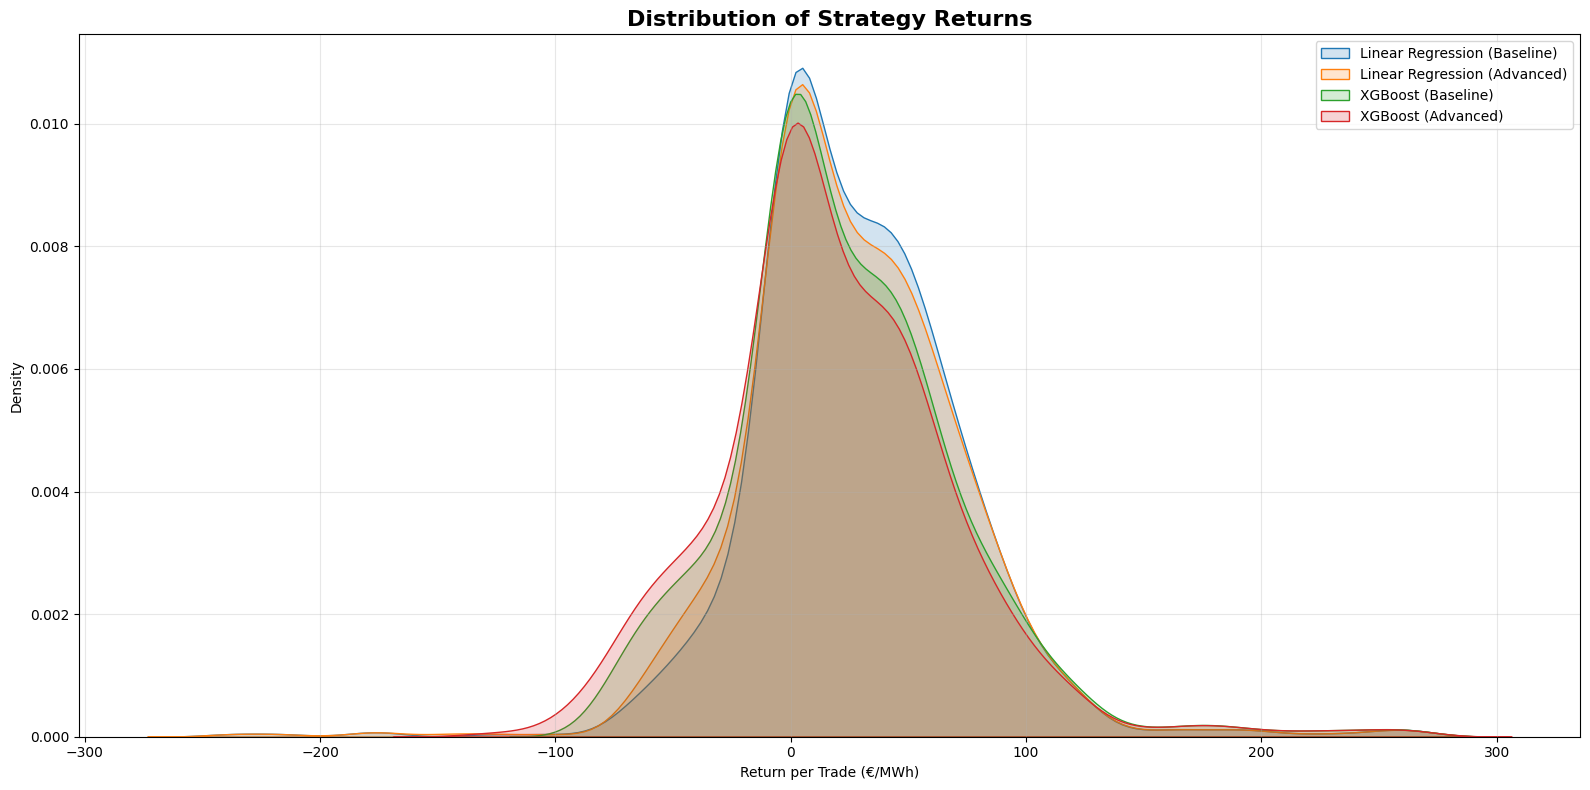


TRADING STRATEGY SUMMARY (Simple Long/Short)
              total_return  avg_return  std_return  sharpe_daily  hit_rate  \
lr_baseline       26252.86      28.078      45.709         3.009     0.728   
lr_advanced       24503.26      26.207      47.038         2.729     0.711   
xgb_baseline      21357.06      22.842      48.466         2.309     0.652   
xgb_advanced      17352.49      18.559      50.710         1.793     0.621   

              long_ratio  short_ratio  flat_ratio  
lr_baseline        0.517        0.465       0.018  
lr_advanced        0.473        0.510       0.017  
xgb_baseline       0.718        0.263       0.019  
xgb_advanced       0.686        0.305       0.010  

Notes:
- Neutral band set at ±1.0 €/MWh to filter choppy signals.
- Returns assume one unit exposure per trade with no transaction costs.
- Sharpe ratios annualised to daily frequency (sqrt(24) scaling).


In [43]:
# Simple trading strategy based on model forecasts
neutral_band = 1.0  # €/MWh band where we stay flat

strategy_df = test_df_best.copy()
strategy_df = strategy_df.assign(
    actual_target=y_test_array,
    current_price=test_df_best['price'].values
)

price_change = strategy_df['actual_target'] - strategy_df['current_price']
trading_metrics = {}
equity_curves = {}

for model_name in model_order:
    preds = predictions_best[model_name]
    raw_signal = preds - strategy_df['current_price']
    signal = np.where(raw_signal > neutral_band, 1, np.where(raw_signal < -neutral_band, -1, 0))
    returns = signal * price_change
    equity_curve = returns.cumsum()

    strategy_df[f'{model_name}_signal'] = signal
    strategy_df[f'{model_name}_returns'] = returns
    equity_curves[model_name] = equity_curve

    total_return = returns.sum()
    avg_return = returns.mean()
    return_std = returns.std(ddof=1)
    sharpe_hourly = np.nan if return_std == 0 else (avg_return / return_std)
    sharpe_daily = np.nan if np.isnan(sharpe_hourly) else sharpe_hourly * np.sqrt(24)
    hit_rate = (returns > 0).mean()

    trading_metrics[model_name] = {
        'total_return': total_return,
        'avg_return': avg_return,
        'std_return': return_std,
        'sharpe_hourly': sharpe_hourly,
        'sharpe_daily': sharpe_daily,
        'hit_rate': hit_rate,
        'long_ratio': (signal == 1).mean(),
        'short_ratio': (signal == -1).mean(),
        'flat_ratio': (signal == 0).mean()
    }

# Plot equity curves
plt.figure(figsize=(16, 8))
for model_name in model_order:
    plt.plot(strategy_df.index, equity_curves[model_name], label=model_display_names[model_name], linewidth=2)
plt.title('Equity Curves: Simple Long/Short Strategy', fontsize=16, fontweight='bold')
plt.xlabel('Time')
plt.ylabel('Cumulative Return (€/MWh)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Visualise distribution of returns for each model
plt.figure(figsize=(16, 8))
for model_name in model_order:
    sns.kdeplot(strategy_df[f'{model_name}_returns'], label=model_display_names[model_name], fill=True, alpha=0.2)
plt.title('Distribution of Strategy Returns', fontsize=16, fontweight='bold')
plt.xlabel('Return per Trade (€/MWh)')
plt.ylabel('Density')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Summarise trading metrics
metrics_df = pd.DataFrame(trading_metrics).T
metrics_df = metrics_df[['total_return', 'avg_return', 'std_return', 'sharpe_daily', 'hit_rate', 'long_ratio', 'short_ratio', 'flat_ratio']]
print('\n' + '=' * 80)
print('TRADING STRATEGY SUMMARY (Simple Long/Short)')
print('=' * 80)
print(metrics_df.round(3))
print('\nNotes:')
print(f'- Neutral band set at ±{neutral_band:.1f} €/MWh to filter choppy signals.')
print('- Returns assume one unit exposure per trade with no transaction costs.')
print('- Sharpe ratios annualised to daily frequency (sqrt(24) scaling).')
